# EDA completo de imágenes DESI y propiedades de las galaxias

**Proyecto:** Inferencia de propiedades físicas de galaxias a partir de imágenes.  
**Instituto Tecnológico y de Estudios Superiores de Monterrey (ITESM)** · Maestría en Inteligencia Artificial.  
**Colaboración científica:** Instituto de Astronomía de la Universidad Nacional Autónoma de México (IA-UNAM).

José Florencio Maguey Peralta — A01796727  
Erick Alberto Bustos Cruz — A01378966  
Luz Copelia Minutti Pérez — A01796921

**Asesores:** Dr. Iván Reyes Amezcua; Dr. Héctor Hernández Toledo; Dr. José Antonio Vázquez Mata.

Examinamos las imágenes de DESI Legacy Imaging Surveys, su correspondencia con nuestro catálogo candidato y las propiedades de referencia de Pipe3D. Buscamos describir la disponibilidad, las distribuciones y las incidencias que pueden afectar la inferencia de **masa estelar, tasa de formación estelar e índice D4000**. Este análisis prepara la interpretación científica y la evaluación posterior del experimento.

El universo previsto es de **9,661 galaxias**. Procesamos todas las filas del archivo suministrado y mostramos cuántas tienen datos efectivamente disponibles. Las **300 galaxias de desarrollo** constituyen un antecedente provisional; no limitan este notebook.

**Versión 1.1.0 — revisión del 2 de octubre de 2026.**


### Propósito de esta primera etapa

Describimos la población disponible y evaluamos qué limitaciones debemos tener presentes antes de estimar sus tres propiedades físicas. Nuestra unidad principal de análisis es la **galaxia**; para estudiar las imágenes distinguimos además el archivo FITS, el plano de cada banda y sus píxeles. Esta distinción evita interpretar 28,983 planos como si fueran 28,983 galaxias independientes.

El alcance de esta entrega es **descriptivo y diagnóstico**. Conservamos la muestra para reconocer problemas, relacionarlos con sus metadatos y preparar la revisión científica. Las decisiones adicionales que planteamos son provisionales y podrán revisarse con los asesores; no las presentamos como criterios de aceptación ya aprobados ni como operaciones ejecutadas sobre los datos. Los hallazgos corresponden a nuestras candidatas y no se extrapolan automáticamente a toda la población de MaNGA o de DESI.


## 1. Alcance, acuerdos y lectura de resultados

Conservamos la geometría acordada con los asesores: archivos originales de **800 × 800 píxeles**, bandas **g, r y z**, y escala solicitada de **0.262 arcsec/píxel**. Leemos el cubo como un arreglo de tres canales y comprobamos su orden en el encabezado. También admitimos los archivos antiguos que contienen una banda cada uno.

Comparamos el campo original con su región central de **300 × 300 píxeles a la misma escala**. Extraemos esa región únicamente en memoria para describirla y mostrarla. No remuestreamos, interpolamos ni guardamos nuevas imágenes. Sus campos nominales son:

| Campo | Píxeles | Lado angular |
|---|---:|---:|
| Original | 800 × 800 | 209.6 arcsec |
| Centro | 300 × 300 | 78.6 arcsec |

Los valores de **Petro90/R90 de NSA** aportan una referencia de tamaño angular. Comparamos $D_{90}=2R_{90}$ con el campo, sin interpretar esa comparación como una medición directa de cuánto flujo DESI conserva cada recorte.

El EDA incluye todos los grupos QC. La decisión vigente del proyecto **excluye WARNING y BAD del experimento**, conservándolos en el catálogo para trazabilidad. No cambiamos las particiones Train, Validation y Test. La exploración de imágenes para orientar decisiones se concentra por defecto en Train; los resúmenes por partición permiten describir diferencias sin ajustar decisiones al desempeño de Test.

**No aplicamos nuevas exclusiones, imputaciones, correcciones fotométricas, segmentación, normalización de entrenamiento ni entrenamiento de modelos.** Los parámetros de visualización y las tolerancias numéricas se documentan como decisiones técnicas; no son nuevos cortes científicos.


## 2. Antes de ejecutar

Usamos el catálogo completo y los cubos de la cuenta de Drive que contiene `DESI_Candidatas_800_GRZ`. La configuración ya apunta a las rutas documentadas del proyecto. Si trabajamos en otra cuenta, ajustamos **BASE_DRIVE** y, cuando corresponda, **CARPETA_FITS** en la celda de configuración.

1. Leemos `catalogo_candidatas_original.csv`; esperamos **9,661 candidatas** y conservamos todas sus etiquetas, flags y particiones.
2. Recorremos la carpeta de descarga y sus subcarpetas. Reconocemos nombres como `1-421128_2b07c803676a_800px_grz.fits`. No necesitamos un `inventario.csv` anterior ni suponemos que los registros del descargador acrediten la lectura de los FITS.
3. Asociamos por MANGAID y distinguimos ausencia local, archivos vacíos, nombres no reconocidos y varios archivos para una misma galaxia. No elegimos arbitrariamente entre duplicados.
4. Abrimos cada cubo para verificar su lectura, los tres planos, el encabezado, la geometría y los valores. **Un archivo presente no equivale a un archivo íntegro ni a una imagen científicamente adecuada.**

**CPU es suficiente.** Procesamos una galaxia a la vez; no cargamos todas las imágenes ni copiamos los FITS a otra carpeta. Leer toda la muestra exige recorrer decenas de GB desde Drive y puede tardar. La barra de progreso indica cuántas galaxias se revisaron y cuántas estadísticas se recuperaron.

Ejecutamos las celdas en orden. La celda de lectura es la más larga. Si Colab se desconecta, volvemos a ejecutar desde el inicio con la misma configuración y carpeta de resultados: se recuperan las estadísticas guardadas, se detectan archivos nuevos o cambiados y se reintentan errores de lectura. El avance se guarda cada 25 galaxias y también al interrumpir normalmente la celda. Si el proceso termina abruptamente, puede repetirse el último lote.

**Petro90:** si el archivo del asesor está en esta cuenta, colocamos `petro90.csv` junto al catálogo, o indicamos su ruta exacta en `th90_csv`. Su ausencia no impide el resto del EDA, pero deja pendientes las comparaciones basadas en R90. Las imágenes SDSS, mapas IVAR/NEXP y la lista histórica de 300 son opcionales; sus rutas permanecen vacías si no están disponibles.

La lectura desde el Drive montado comprueba que los archivos son accesibles en esa sesión. No sustituye una verificación independiente de sincronización remota. Este cuaderno no inicia descargas astronómicas ni entrenamiento.


In [1]:
# Dependencias; instalamos únicamente los paquetes ausentes en esta sesión.
import importlib.util,subprocess,sys
paquetes={'numpy':'numpy','pandas':'pandas','matplotlib':'matplotlib','astropy':'astropy',
          'PIL':'pillow','scipy':'scipy','pypdf':'pypdf','IPython':'ipython'}
faltan=[p for modulo,p in paquetes.items() if importlib.util.find_spec(modulo) is None]
if faltan:subprocess.check_call([sys.executable,'-m','pip','install','-q',*faltan])
print('Dependencias disponibles.')


Dependencias disponibles.


In [2]:
# En Colab, montamos la cuenta de Drive que contiene los FITS y el catálogo.
# Fuera de Colab, usamos rutas locales en la configuración.
try:
    from google.colab import drive
except ImportError:
    print('Entorno local: configura rutas del equipo.')
else:
    drive.mount('/content/drive')


Mounted at /content/drive


## 3. Configuración

La modalidad predeterminada es **ESCANEO**: buscamos archivos en la carpeta conocida y asociamos el MANGAID completo del nombre con el catálogo. El código hexadecimal intermedio forma parte del nombre del archivo; no es otro identificador de galaxia. Solo leemos las rutas asociadas de manera única.

También conservamos `CSV` para un inventario explícito y `PATRON` para nombres exactos sin sufijos variables. Estas alternativas no se activan durante esta ejecución. En CSV requerimos una fila por galaxia; las rutas relativas se interpretan respecto a la carpeta de ese CSV.

Mantenemos los acuerdos de **800 × 800 píxeles y 0.262 arcsec/píxel**, con una comparación central de **300 × 300 sin remuestreo**. Mostramos ejemplos de Train; conservamos las estadísticas por Train, Validation y Test. No aplicamos exclusiones por QCFLAG en el EDA.

Las opciones de visualización solo cambian las gráficas. Los umbrales numéricos comparan metadatos; no son nuevos cortes científicos. Confirmamos el orden g/r/z con el encabezado, sin asumirlo por el nombre.


In [3]:
from pathlib import Path

# ACTUALIZA BASE_DRIVE solo si tus archivos están en otra carpeta o cuenta montada.
BASE_DRIVE = Path('/content/drive/MyDrive/DESI_Candidatas_800_GRZ')
# ACTUALIZA si cambió el nombre de la descarga. Se recorren también sus subcarpetas.
CARPETA_FITS = BASE_DRIVE / 'descarga_22fb149046f162f3'
# Opcional: copia aquí el petro90.csv del asesor o cambia th90_csv más abajo.
TH90_LOCAL = BASE_DRIVE / 'petro90.csv'
CFG = {
    'catalogo_csv': str(BASE_DRIVE / 'catalogo_candidatas_original.csv'),
    'carpeta_resultados': str(BASE_DRIVE / 'resultados_eda'),
    'nombre_eda': 'EDA_DESI_candidatas_800_GRZ_v1_1',
    'candidatas_esperadas': 9661,
    # ESCANEO: descubre los FITS existentes, sin exigir inventario.csv.
    # Alternativas: CSV con rutas explícitas, o PATRON con nombres exactos.
    'modo_rutas': 'ESCANEO',
    'formato_entrada': 'CUBOS',  # Alternativa: BANDAS_SEPARADAS.
    'inventario_csv': '',
    'columna_id_inventario': 'mangaid',  # ACTUALIZA si el descargador usa 'identificador'.
    'columna_ruta_cubo': 'ruta',  # ACTUALIZA: 'ruta_fits', 'ruta' u otra columna existente.
    'columnas_rutas_bandas': {'g':'ruta_g','r':'ruta_r','z':'ruta_z'},
    'carpeta_imagenes': str(CARPETA_FITS),
    # ESCANEO: nombre completo documentado; no son coincidencias parciales.
    'regex_cubo': r'^(?P<mangaid>\d+-\d+)_[0-9a-f]{12}_800px_grz\.fits(?:\.gz)?$',
    # Solo PATRON: ACTUALIZA el patrón exacto. No se deduce identidad de coincidencias parciales.
    'patron_cubo': 'ACTUALIZA_{mangaid}_800px_grz.fits',
    'patron_banda': 'ACTUALIZA_{mangaid}_{banda}.fits',
    'hdu_imagen': 0,
    # Acuerdos científicos existentes. EDA registra diferencias; no las corrige.
    'bandas': ['g','r','z'], 'lado_original': 800, 'lado_recorte': 300,
    'escala_arcsec_pixel': 0.262,
    'mapa_split': {'Train':'Train','Validation':'Validation','Test':'Test'},
    # Si falta declaración de bandas, NO asumimos el orden.
    # Solo completar con evidencia: p.ej. ['g','r','z'] y una justificación.
    'orden_cubo_sin_header': None,
    'justificacion_orden_manual': 'ACTUALIZA_SOLO_SI_FALTA_EL_HEADER_DE_BANDAS',
    # Opcionales, no necesarios para leer las imágenes.
    'th90_csv': str(TH90_LOCAL) if TH90_LOCAL.is_file() else '',  # petro90.csv del asesor: columnas MANGAID,PETRO_TH90, unidad arcsec.
    'columna_id_th90': 'MANGAID', 'columna_radio_th90': 'PETRO_TH90',
    'columna_r90_en_catalogo': '',  # ACTUALIZA si ya existe una columna confirmada en arcsec.
    'ids_desarrollo_csv': '',  # Lista de las 300 usadas antes; columna mangaid.
    'revision_visual_csv': '',  # Copia completada de la plantilla que generará este notebook.
    # Mapas opcionales en el mismo inventario: ruta_ivar_g/r/z o ruta_nexp_g/r/z.
    # Valores >0 indican soporte; deben coincidir en forma y WCS con el FITS científico.
    'tipo_mapa_cobertura': None,  # ACTUALIZA a 'IVAR' o 'NEXP' si realmente tienes esos mapas.
    'hdu_mapa_cobertura': 0,
    # Caché de estadísticas. Guarda cada 25 galaxias; reanuda sin repetir éxitos sin cambios.
    'galaxias_por_guardado': 25,
    'reintentar_errores': True,  # Repite fallos: Drive puede haber estado temporalmente inaccesible.
    'forzar_relectura': False,  # ACTUALIZA a True solo para ignorar la caché y releer todos los FITS.
    # Tolerancias NUMÉRICAS para comparar WCS; no son cortes de selección astronómica.
    'tolerancia_escala_arcsec': 1e-5,
    'tolerancia_wcs_arcsec': 0.01,
    'tolerancia_centrado_pix': 0.5,
    # Exploración de imágenes en Train para orientar decisiones; estadísticas globales por partición.
    'particiones_galerias': ['Train'],
    'semilla_galerias': 42, 'n_ejemplos_por_galeria': 6,
    # Franja de bordes: descriptor exploratorio; NO se utiliza como estimación de cielo ni se sustrae.
    'ancho_borde_pix': 50,
    'percentiles_visualizacion': [0.5,99.5], 'asinh_visualizacion': 0.1,
    # Perfiles del CAMPO observado, sin aislamiento ni nueva sustracción de fondo.
    'hacer_perfiles_diagnosticos': True, 'n_perfiles': 3, 'anillos_perfil': 35,
    'ids_galeria_adicional': ['1-290015', '1-558624'],  # ACTUALIZA opcionalmente con mangaid que quieras revisar.
    # Comparación opcional: imágenes SDSS YA exportadas en PNG/JPG, sin deserializar cargadores.
    'inventario_sdss_csv': '',  # columnas mangaid,ruta_imagen; rutas relativas al CSV.
}
print('=== CONFIGURACIÓN ===')
print('Catálogo:', CFG['catalogo_csv'])
print('Cubos:', CFG['carpeta_imagenes'])
print('Resultados:', Path(CFG['carpeta_resultados']) / CFG['nombre_eda'])
print('Modalidad: ESCANEO | candidatos previstos: 9,661')
print('Original: 800 × 800, 0.262 arcsec/píxel | comparación central: 300 × 300')
print('Petro90:', CFG['th90_csv'] or 'PENDIENTE: indicar el archivo del asesor para el análisis de radios.')
print('Solo se preparó la configuración; todavía no se abrieron los FITS.')


=== CONFIGURACIÓN ===
Catálogo: /content/drive/MyDrive/DESI_Candidatas_800_GRZ/catalogo_candidatas_original.csv
Cubos: /content/drive/MyDrive/DESI_Candidatas_800_GRZ/descarga_22fb149046f162f3
Resultados: /content/drive/MyDrive/DESI_Candidatas_800_GRZ/resultados_eda/EDA_DESI_candidatas_800_GRZ_v1_1
Modalidad: ESCANEO | candidatos previstos: 9,661
Original: 800 × 800, 0.262 arcsec/píxel | comparación central: 300 × 300
Petro90: PENDIENTE: indicar el archivo del asesor para el análisis de radios.
Solo se preparó la configuración; todavía no se abrieron los FITS.


In [4]:
import os,sys,json,hashlib,re,gc,math,time,zipfile,textwrap,warnings,platform
from pathlib import Path
from datetime import datetime,timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Rectangle,Ellipse
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.visualization import ImageNormalize,AsinhStretch
from PIL import Image
from IPython.display import display
VERSION_EDA='1.1.0'
BANDAS=['g','r','z']; OBJETIVOS=['log_mstar','log_sfr','d4000']
ERRORES=['error_log_mstar','error_log_sfr','error_d4000']
QC={0:('OK','Controles del catálogo superados'),1:('BAD','Redshift incorrecto'),
    2:('BAD','Baja señal/ruido o campo vacío'),3:('WARNING','Ajuste y/o AGN intenso'),
    4:('WARNING','Masa discrepante con NSA'),5:('WARNING','Redshift discrepante con NSA'),
    6:('WARNING','Estrella en primer plano'),7:('WARNING','Sistema en fusión')}
COLORES_QC={'OK':'#2166ac','WARNING':'#df8b19','BAD':'#b2182b','DESCONOCIDO':'#777777'}
FIGURAS=[]
PRODUCTOS=[]

def pendiente(x):return isinstance(x,str) and 'ACTUALIZA' in x

def firma(obj):return hashlib.sha256(json.dumps(obj,sort_keys=True,ensure_ascii=False,allow_nan=False).encode()).hexdigest()

def sha_archivo(p):
    h=hashlib.sha256()
    with open(p,'rb') as f:
        for bloque in iter(lambda:f.read(1024**2),b''):h.update(bloque)
    return h.hexdigest()

def guardar_json(obj,p):
    p=Path(p);p.parent.mkdir(parents=True,exist_ok=True);tmp=p.with_name(p.name+'.tmp')
    tmp.write_text(json.dumps(obj,ensure_ascii=False,indent=2,allow_nan=False),encoding='utf-8');os.replace(tmp,p)
    if p not in PRODUCTOS:PRODUCTOS.append(p)

def guardar_csv(df,p):
    p=Path(p);p.parent.mkdir(parents=True,exist_ok=True);tmp=p.with_name(p.name+'.tmp')
    df.to_csv(tmp,index=False);os.replace(tmp,p)
    if p not in PRODUCTOS:PRODUCTOS.append(p)

def registrar_pdf(p):
    p=Path(p)
    if p not in FIGURAS:FIGURAS.append(p)

def terminar_figura(fig,p,mostrar=True):
    p=Path(p);tmp=p.with_name(p.name+'.tmp')
    with PdfPages(tmp) as pdf:
        pdf.savefig(fig,bbox_inches='tight',dpi=120)
    os.replace(tmp,p);registrar_pdf(p)
    if mostrar:plt.show()
    plt.close(fig)

def finitos(s):
    v=pd.to_numeric(s,errors='coerce').to_numpy(float)
    return v[np.isfinite(v)]

def resumen(s):
    v=finitos(s)
    if not len(v):return {'n_finitos':0}
    q=np.percentile(v,[1,25,50,75,95,99])
    return {'n_finitos':len(v),'media':float(v.mean()),'mediana':float(q[2]),
        'std':float(v.std(ddof=1)) if len(v)>1 else np.nan,'min':float(v.min()),
        'p01':float(q[0]),'q1':float(q[1]),'q3':float(q[3]),'iqr':float(q[3]-q[1]),
        'p95':float(q[4]),'p99':float(q[5]),'max':float(v.max())}

def ecdf(ax,v,label,**kw):
    v=np.sort(finitos(pd.Series(v)))
    if len(v):ax.plot(v,np.arange(1,len(v)+1)/len(v),label=f'{label} (n={len(v):,})',**kw)


## 4. Catálogo, identidad y propiedades físicas

Mantenemos un registro por `mangaid`, sin resolver duplicados arbitrariamente. Asociamos el radio auxiliar por MANGAID, conforme al acuerdo previo. Si hay varias filas para un mismo identificador en el archivo de radios, registramos la ambigüedad y dejamos esa asociación pendiente.

| Variable | Interpretación | Escala de trabajo |
|---|---|---|
| `log_mstar` | Logaritmo decimal de la masa estelar de referencia | $log_{10}(M_star/M_odot)$; diferencias en dex |
| `log_sfr` | Logaritmo decimal de la tasa de formación estelar de referencia | $log_{10}[mathrm{SFR}/(M_odot,mathrm{año}^{-1})]$; diferencias en dex |
| `d4000` | Índice espectral del salto alrededor de 4000 Å; indicador de población estelar que también depende de metalicidad y de la definición del índice | Adimensional; conservamos la definición de la etiqueta de origen |
| `redshift` | Corrimiento espectral al rojo | Adimensional; auxiliar para interpretar distribuciones |
| `error_*` | Incertidumbres registradas en las fuentes de las etiquetas | Misma escala de la variable correspondiente, pendiente de verificar contra el diccionario de origen si no está documentada |

No aplicamos un segundo logaritmo a las etiquetas que ya están en escala logarítmica. No convertimos una incertidumbre reportada en garantía de ausencia de sesgo: pueden existir errores sistemáticos, problemas de ajuste o asociaciones incorrectas que no estén resumidos por ella. Las estadísticas de este notebook describen los campos recibidos; su interpretación requiere conservar la procedencia y definición de las etiquetas.

`mangaid` sirve para identidad y trazabilidad, no como característica predictiva. Train/Validation/Test son particiones existentes, no clases físicas. El proyecto es de regresión; describimos rangos poco poblados y diferencias de distribuciones, en lugar de hablar de balance de clases de las tres salidas.


### 4.1. Notación física y papel de las variables

Expresamos los objetivos mediante la siguiente notación:

$$y_M=\log_{10}\!\left(\frac{M_\star}{M_\odot}\right),\qquad
 y_{\mathrm{SFR}}=\log_{10}\!\left(\frac{\mathrm{SFR}}{M_\odot\,\mathrm{año}^{-1}}\right),\qquad
 y_D=D4000.$$

La masa estelar se refiere al contenido estelar estimado, no a la masa total de gas y materia oscura. La SFR representa masa formada en estrellas por unidad de tiempo; sus valores logarítmicos negativos corresponden a tasas inferiores a una masa solar por año, no a una formación estelar negativa. D4000 es una razón espectral adimensional: lo utilizamos como etiqueta de población estelar, sin convertirlo directamente en una edad. Conservamos su definición de origen y no intercambiamos distintas versiones del índice.

Estas tres variables son **respuestas de regresión**. Las imágenes constituyen la información observacional para el experimento posterior; en cambio, MANGAID, las rutas y las particiones organizan y documentan la muestra. Redshift, Petro90 y QCFLAG se emplean aquí como variables auxiliares de interpretación y control. Su presencia en el EDA no implica que deban incorporarse como entradas del modelo.


In [5]:
def iniciar(cfg):
    FIGURAS.clear();PRODUCTOS.clear()
    for c in ['catalogo_csv','carpeta_resultados','nombre_eda']:
        if pendiente(cfg[c]) or not cfg[c]:raise ValueError('ACTUALIZA '+c)
    if not Path(cfg['catalogo_csv']).is_file():
        raise FileNotFoundError('No está accesible el catálogo: '+cfg['catalogo_csv']+
            '\nComprueba la cuenta montada y BASE_DRIVE; no lo interpretamos como datos perdidos.')
    if cfg['modo_rutas']=='ESCANEO' and not Path(cfg['carpeta_imagenes']).is_dir():
        raise FileNotFoundError('No está accesible la carpeta FITS: '+cfg['carpeta_imagenes']+
            '\nComprueba CARPETA_FITS y la cuenta de Drive antes de continuar.')
    if not 0 < cfg['lado_recorte'] <= cfg['lado_original']:
        raise ValueError('lado_recorte debe ser positivo y no superar lado_original.')
    if cfg['galaxias_por_guardado'] < 1:
        raise ValueError('galaxias_por_guardado debe ser positivo.')
    cat=pd.read_csv(cfg['catalogo_csv'],dtype={'mangaid':'string'},keep_default_na=False)
    if cat.empty:raise ValueError('El catálogo está vacío.')
    req=['mangaid','RA_Pipe3D','DEC_Pipe3D','split_proyecto','QCFLAG_original',*OBJETIVOS]
    if not set(req).issubset(cat):raise ValueError('Faltan columnas: '+str(set(req)-set(cat)))
    out=Path(cfg['carpeta_resultados'])/cfg['nombre_eda'];out.mkdir(parents=True,exist_ok=True)
    disponibles=[]
    for c in cat:
        texto=cat[c].astype(str).str.strip().str.lower()
        aus=cat[c].isna()|texto.isin(['','nan','null','none'])
        disponibles.append({'columna':c,'registros':len(cat),'ausencias_o_textos_ausencia':int(aus.sum()),
                             'valores_distintos_no_vacios':int(cat.loc[~aus,c].nunique())})
    guardar_csv(pd.DataFrame(disponibles),out/'disponibilidad_columnas.csv')
    cat['mangaid']=cat.mangaid.str.strip()
    dup=cat.mangaid.duplicated(keep=False)|cat.mangaid.eq('')|cat.mangaid.isna()
    guardar_csv(cat.loc[dup],out/'identificadores_a_revisar.csv')
    if dup.any():raise ValueError('Resuelve identificadores_a_revisar.csv: no deduplicamos ni asociamos arbitrariamente.')
    print(f'Catálogo: {len(cat):,} | esperado según proyecto: {cfg["candidatas_esperadas"]:,}')
    if len(cat)!=cfg['candidatas_esperadas']:print('ATENCIÓN: el tamaño difiere; el EDA describirá el archivo suministrado.')
    conversiones=[]
    for c in ['RA_Pipe3D','DEC_Pipe3D','redshift',*OBJETIVOS,*ERRORES,'QCFLAG_original']:
        if c in cat:
            raw=cat[c];aus=raw.isna()|raw.astype(str).str.strip().str.lower().isin(['','nan','null','none'])
            val=pd.to_numeric(raw,errors='coerce')
            conversiones.append({'variable':c,'ausentes_o_textos_ausencia':int(aus.sum()),'no_interpretables':int((val.isna()&~aus).sum()),'infinitos':int(np.isinf(val).sum())})
            cat[c]=val
    guardar_csv(pd.DataFrame(conversiones),out/'conversion_numerica_catalogo.csv')
    cat['coordenadas_en_rango']=np.isfinite(cat.RA_Pipe3D)&np.isfinite(cat.DEC_Pipe3D)&cat.RA_Pipe3D.ge(0)&cat.RA_Pipe3D.lt(360)&cat.DEC_Pipe3D.between(-90,90)
    cat['particion']=cat.split_proyecto.map(cfg['mapa_split']).fillna('NO_RECONOCIDA')
    cat['grupo_qc']=cat.QCFLAG_original.map({k:v[0] for k,v in QC.items()}).fillna('DESCONOCIDO')
    cat['decision_experimento_vigente']=np.select([cat.grupo_qc.eq('WARNING'),cat.grupo_qc.eq('BAD'),cat.grupo_qc.eq('OK')],
        ['WARNING excluida del experimento','BAD excluida provisionalmente','Sin exclusión por QCFLAG'],default='Pendiente de interpretar')
    # Asociación de radio por MANGAID, acordada previamente. No elegimos entre duplicados.
    radio_previo=cat[cfg['columna_r90_en_catalogo']].copy() if cfg['columna_r90_en_catalogo'] in cat else None
    cat['r90_arcsec']=np.nan
    fuente_radio={'estado':'No suministrado'}
    if cfg['th90_csv']:
        r=pd.read_csv(cfg['th90_csv'],dtype={cfg['columna_id_th90']:'string'})
        r=r[[cfg['columna_id_th90'],cfg['columna_radio_th90']]].rename(columns={cfg['columna_id_th90']:'mangaid',cfg['columna_radio_th90']:'radio'})
        r['mangaid']=r.mangaid.str.strip(); r=r.loc[r.mangaid.isin(cat.mangaid)]
        r['duplicado']=r.mangaid.duplicated(keep=False)
        guardar_csv(r.loc[r.duplicado],out/'radios_ambiguos.csv')
        unicos=r.loc[~r.duplicado].set_index('mangaid').radio
        cat['r90_arcsec']=pd.to_numeric(cat.mangaid.map(unicos),errors='coerce')
        cat['estado_radio']=np.where(cat.mangaid.isin(r.loc[r.duplicado,'mangaid']),'Asociación ambigua',
                                    np.where(cat.mangaid.isin(unicos.index),'Asociado por MANGAID','Sin coincidencia'))
        fuente_radio={'archivo':cfg['th90_csv'],'sha256':sha_archivo(cfg['th90_csv']),'unidad_confirmada':'arcsec','origen':'NSA, archivo del asesor'}
    elif cfg['columna_r90_en_catalogo']:
        col=cfg['columna_r90_en_catalogo']
        if col not in cat:raise ValueError('No existe la columna de radio indicada.')
        cat['r90_arcsec']=pd.to_numeric(radio_previo,errors='coerce');cat['estado_radio']='Columna del catálogo'
        fuente_radio={'columna':col,'unidad_confirmada':'arcsec'}
    else:cat['estado_radio']='No suministrado'
    cat['radio_utilizable']=np.isfinite(cat.r90_arcsec)&cat.r90_arcsec.gt(0)
    cat['d90_arcsec']=2*cat.r90_arcsec
    cat['es_desarrollo_previo']=False
    if cfg['ids_desarrollo_csv']:
        dev=pd.read_csv(cfg['ids_desarrollo_csv'],dtype={'mangaid':'string'})
        if 'mangaid' not in dev:raise ValueError('Lista de desarrollo sin mangaid.')
        cat['es_desarrollo_previo']=cat.mangaid.isin(dev.mangaid.str.strip())
    manifiesto={'version_codigo':VERSION_EDA,'fecha_utc':datetime.now(timezone.utc).isoformat(),
      'catalogo':cfg['catalogo_csv'],'sha256_catalogo':sha_archivo(cfg['catalogo_csv']),
      'fuente_radio':fuente_radio,'configuracion':cfg,'versiones':{'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__}}
    guardar_json(manifiesto,out/'manifiesto_eda.json')
    guardar_csv(cat,out/'catalogo_eda.csv')
    print('Radios finitos y positivos:', int(cat.radio_utilizable.sum()), '/', len(cat))
    if not cat.radio_utilizable.any():print('Petro90 pendiente: no se inferirán radios a partir de las imágenes.')
    display(cat.groupby(['particion','grupo_qc']).size().rename('galaxias').reset_index())
    return cat,out


In [6]:
from google.colab import files
from pathlib import Path
from io import BytesIO
import pandas as pd
import tempfile

print("Selecciona el archivo petro90.csv del asesor.")
subidos = files.upload()

if len(subidos) != 1:
    raise ValueError("Selecciona únicamente el archivo Petro90.")

nombre, contenido = next(iter(subidos.items()))

# Revisamos las columnas antes de incorporar el archivo.
tabla = pd.read_csv(
    BytesIO(contenido),
    dtype={"MANGAID": "string"}
)

requeridas = {"MANGAID", "PETRO_TH90"}
faltantes = requeridas - set(tabla.columns)

if faltantes:
    raise ValueError(
        f"Faltan columnas en el archivo: {sorted(faltantes)}"
    )

# Guardamos una copia temporal con el contenido original intacto.
carpeta_temporal = Path(
    tempfile.mkdtemp(prefix="th90_asesor_", dir="/content")
)
ruta_th90 = carpeta_temporal / Path(nombre).name
ruta_th90.write_bytes(contenido)

# Unidad confirmada previamente con el asesor: arcsec.
CFG["th90_csv"] = str(ruta_th90)
CFG["columna_id_th90"] = "MANGAID"
CFG["columna_radio_th90"] = "PETRO_TH90"

print(f"\nArchivo cargado: {nombre}")
print(f"Registros del archivo auxiliar: {len(tabla):,}")

# Repetimos la asociación del catálogo incorporando Petro90.
catalogo_eda, CARPETA_EDA = iniciar(CFG)

print("\nContinúa con la celda del inventario físico de imágenes.")
print("No se modificaron los FITS ni el archivo original del asesor.")

Selecciona el archivo petro90.csv del asesor.


Saving petro90.csv to petro90.csv

Archivo cargado: petro90.csv
Registros del archivo auxiliar: 10,126
Catálogo: 9,661 | esperado según proyecto: 9,661
Radios finitos y positivos: 9652 / 9661


,particion,grupo_qc,galaxias
0,Test,BAD,1
1,Test,OK,918
2,Test,WARNING,50
3,Train,BAD,5
4,Train,OK,7123
5,Train,WARNING,262
6,Validation,OK,1262
7,Validation,WARNING,40



Continúa con la celda del inventario físico de imágenes.
No se modificaron los FITS ni el archivo original del asesor.


In [7]:
from pathlib import Path
from io import BytesIO
import pandas as pd
import tempfile

# Recuperamos la ruta de la celda de carga anterior.
ruta_previa = globals().get("ruta_th90")
ruta = Path(ruta_previa) if ruta_previa else None

if ruta is None or not ruta.is_file():
    from google.colab import files

    print("Selecciona petro90.csv del asesor.")
    subidos = files.upload()

    if len(subidos) != 1:
        raise ValueError("Selecciona únicamente el archivo Petro90.")

    nombre, contenido = next(iter(subidos.items()))
    tabla = pd.read_csv(
        BytesIO(contenido), dtype={"MANGAID": "string"}
    )

    carpeta = Path(tempfile.mkdtemp(prefix="th90_", dir="/content"))
    ruta = carpeta / Path(nombre).name
    ruta.write_bytes(contenido)
else:
    tabla = pd.read_csv(ruta, dtype={"MANGAID": "string"})

faltantes = {"MANGAID", "PETRO_TH90"} - set(tabla.columns)
if faltantes:
    raise ValueError(f"Faltan columnas: {sorted(faltantes)}")

ruta_th90 = ruta
CFG["th90_csv"] = str(ruta)
CFG["columna_id_th90"] = "MANGAID"
CFG["columna_radio_th90"] = "PETRO_TH90"

print("Archivo auxiliar:", CFG["th90_csv"])
print("Registros auxiliares:", len(tabla))

catalogo_eda, CARPETA_EDA = iniciar(CFG)

print("\n=== ESTADO DE LA ASOCIACIÓN ===")
display(
    catalogo_eda["estado_radio"]
    .value_counts(dropna=False)
    .rename_axis("estado")
    .reset_index(name="galaxias")
)

Archivo auxiliar: /content/th90_asesor_2l3nlvqq/petro90.csv
Registros auxiliares: 10126
Catálogo: 9,661 | esperado según proyecto: 9,661
Radios finitos y positivos: 9652 / 9661


,particion,grupo_qc,galaxias
0,Test,BAD,1
1,Test,OK,918
2,Test,WARNING,50
3,Train,BAD,5
4,Train,OK,7123
5,Train,WARNING,262
6,Validation,OK,1262
7,Validation,WARNING,40



=== ESTADO DE LA ASOCIACIÓN ===


,estado,galaxias
0,Asociado por MANGAID,9655
1,Sin coincidencia,6


In [8]:
catalogo_eda, CARPETA_EDA = iniciar(CFG)


Catálogo: 9,661 | esperado según proyecto: 9,661
Radios finitos y positivos: 9652 / 9661


,particion,grupo_qc,galaxias
0,Test,BAD,1
1,Test,OK,918
2,Test,WARNING,50
3,Train,BAD,5
4,Train,OK,7123
5,Train,WARNING,262
6,Validation,OK,1262
7,Validation,WARNING,40


### 4.2. Identidad, cardinalidad y asociación de radios: resultados

Conservamos **9,661 galaxias con identificadores únicos**. La rutina de inicio detiene el análisis ante identificadores vacíos o repetidos, por lo que completar esta comprobación respalda la correspondencia uno a uno dentro del catálogo utilizado. Esto verifica identidad de registros, pero no demuestra por sí solo que la fuente astronómica visible esté correctamente identificada.

| Variable | Cardinalidad observada | Interpretación en el EDA |
|---|---:|---|
| `mangaid` | 9,661 | Identificador; su alta cardinalidad es esperable y útil para la trazabilidad. |
| Partición | 3 | Train, Validation y Test; no son clases físicas. |
| `QCFLAG_original` | 6 códigos presentes | 0, 1, 3, 4, 6 y 7; los códigos 2 y 5 tienen conteo cero. |
| Grupo de calidad | 3 | OK, WARNING y BAD; resumen de las categorías anteriores. |

No interpretamos los códigos QC como una escala numérica continua: un código mayor no equivale necesariamente a una observación peor. Del mismo modo, no proponemos agrupar identificadores para reducir su cardinalidad; su función es enlazar evidencias, no representar características físicas.

El archivo auxiliar contiene 10,126 registros y permite asociar **9,655 candidatas por MANGAID**; seis no tienen coincidencia. De las asociadas, 9,652 tienen radio finito y positivo. Por diferencia, tres asociaciones no proporcionan un radio utilizable. Así, las **nueve candidatas sin radio utilizable** combinan dos situaciones distintas: ausencia de asociación y medida asociada que no satisface el criterio numérico. No asignamos a esos tres valores una causa concreta sin inspeccionarlos individualmente.

Conservamos estas nueve galaxias para los demás análisis y las retiramos únicamente del denominador de las comparaciones que requieren un radio válido. Esta disponibilidad por variable evita eliminar una galaxia completa por carecer de un dato auxiliar. El porcentaje de radios utilizables es aproximadamente **99.91 %** del catálogo.


## 5. Inventario físico y correspondencia con las candidatas

Recorremos los nombres y tamaños antes de abrir las imágenes. Guardamos el listado completo, archivos sin correspondencia, posibles descargas parciales, incidentes de acceso y candidatos con varias rutas. Una galaxia con dos cubos permanece marcada como ambigua hasta revisar sus rutas; no elegimos por fecha ni tamaño.

El resumen distingue **archivos**, **identificadores distintos** y **candidatas**. Solo tras la siguiente auditoría conoceremos cuántas galaxias tienen los tres planos legibles. Si faltan archivos, conservamos las candidatas y sus etiquetas en el EDA; no confundimos ausencia local con falta de cobertura astronómica.


In [9]:
def inventario_fisico_cubos(cat,cfg,out):
    if cfg['formato_entrada']!='CUBOS':
        raise ValueError('ESCANEO está preparado para cubos; para bandas separadas usa CSV o PATRON.')
    if cfg['tipo_mapa_cobertura']:
        raise ValueError('Para asociar mapas de cobertura usa CSV con las rutas explícitas.')
    raiz=Path(cfg['carpeta_imagenes'])
    if not raiz.is_dir():raise FileNotFoundError('Carpeta de cubos no accesible: '+str(raiz))
    patron=re.compile(cfg['regex_cubo'],re.IGNORECASE)
    ids=set(cat.mangaid);registros=[];errores=[];parciales=[]
    def error_recorrido(exc):
        errores.append({'ruta':str(exc.filename or raiz),'detalle':str(exc)})
    print('Revisando nombres y tamaños dentro de:',raiz,flush=True)
    for carpeta,_,nombres in os.walk(raiz,onerror=error_recorrido,followlinks=False):
        for nombre in nombres:
            p=Path(carpeta)/nombre
            if nombre.lower().endswith(('.part','.partial','.tmp')):
                parciales.append({'archivo':nombre,'ruta':str(p)})
            if not nombre.lower().endswith(('.fits','.fits.gz')):continue
            m=patron.fullmatch(nombre);g=m.group('mangaid') if m else ''
            estado='Presente con contenido';tam=None
            try:
                tam=p.stat().st_size
                if tam==0:estado='Archivo vacío'
            except OSError as exc:
                estado='Tamaño no accesible';errores.append({'ruta':str(p),'detalle':str(exc)})
            registros.append({'archivo':nombre,'ruta':str(p),'mangaid':g,'bytes':tam,
                'nombre_reconocido':m is not None,'en_catalogo':g in ids,'estado_presencia':estado})
            if len(registros)%1000==0:print(f'FITS registrados: {len(registros):,}',flush=True)
    columnas=['archivo','ruta','mangaid','bytes','nombre_reconocido','en_catalogo','estado_presencia']
    fisico=pd.DataFrame(registros,columns=columnas)
    guardar_csv(fisico,out/'archivos_fisicos_encontrados.csv')
    guardar_csv(pd.DataFrame(errores,columns=['ruta','detalle']),out/'incidencias_recorrido.csv')
    guardar_csv(pd.DataFrame(parciales,columns=['archivo','ruta']),out/'posibles_archivos_parciales.csv')
    guardar_csv(fisico.loc[~fisico.en_catalogo.astype(bool)],out/'archivos_sin_asociacion_catalogo.csv')
    relacionados=fisico.loc[fisico.en_catalogo.astype(bool)]
    agrupados=relacionados.groupby('mangaid').ruta.agg(list).to_dict()
    conteos={g:len(p) for g,p in agrupados.items()}
    guardar_csv(relacionados.loc[relacionados.mangaid.map(conteos).gt(1)],out/'cubos_duplicados_por_mangaid.csv')
    t=cat.copy();t['n_cubos_encontrados']=t.mangaid.map(conteos).fillna(0).astype(int)
    t['rutas_cubos_encontrados']=t.mangaid.map(lambda g:json.dumps(agrupados.get(g,[]),ensure_ascii=False))
    t['ruta_cubo']=t.mangaid.map(lambda g:agrupados[g][0] if len(agrupados.get(g,[]))==1 else '')
    t['estado_asociacion_archivo']=np.select([t.n_cubos_encontrados.eq(0),t.n_cubos_encontrados.gt(1)],
        ['Sin archivo localizado','Varios cubos; asociación pendiente'],default='Archivo único localizado')
    guardar_csv(t.loc[t.n_cubos_encontrados.eq(0)],out/'candidatas_sin_archivo_localizado.csv')
    guardar_csv(t.loc[t.n_cubos_encontrados.gt(1)],out/'candidatas_con_asociacion_ambigua.csv')
    print(f'Catálogo: {len(t):,} | FITS encontrados: {len(fisico):,} | candidatas con algún archivo: {t.n_cubos_encontrados.gt(0).sum():,}')
    print(f'Asociación única: {t.n_cubos_encontrados.eq(1).sum():,} | ambiguas: {t.n_cubos_encontrados.gt(1).sum():,} | sin archivo localizado: {t.n_cubos_encontrados.eq(0).sum():,}')
    print(f'Incidencias de acceso: {len(errores):,} | posibles archivos parciales: {len(parciales):,}')
    if errores:print('ATENCIÓN: el recorrido tuvo errores; no confirmamos ausencia en ubicaciones inaccesibles.')
    if not len(fisico):print('ATENCIÓN: no se localizaron FITS. Revisa la carpeta antes de la auditoría larga.')
    print('Estos conteos son de presencia; todavía no acreditan integridad ni calidad astronómica.')
    return t

def preparar_inventario(cat,cfg,out):
    if cfg['formato_entrada'] not in ['CUBOS','BANDAS_SEPARADAS']:raise ValueError('Revisa formato_entrada.')
    cols=['ruta_cubo'] if cfg['formato_entrada']=='CUBOS' else ['ruta_'+b for b in BANDAS]
    if cfg['modo_rutas']=='ESCANEO':
        t=inventario_fisico_cubos(cat,cfg,out)
    elif cfg['modo_rutas']=='CSV':
        if pendiente(cfg['inventario_csv']):raise ValueError('ACTUALIZA inventario_csv.')
        inv=pd.read_csv(cfg['inventario_csv'],dtype={cfg['columna_id_inventario']:'string'},keep_default_na=False)
        inv=inv.rename(columns={cfg['columna_id_inventario']:'mangaid'})
        if 'mangaid' not in inv:raise ValueError('Revisa la columna de identidad del inventario.')
        inv['mangaid']=inv.mangaid.str.strip()
        inv=inv.loc[inv.mangaid.isin(cat.mangaid)].copy()
        if inv.mangaid.duplicated().any():
            guardar_csv(inv.loc[inv.mangaid.duplicated(keep=False)],out/'inventario_duplicados.csv')
            raise ValueError('El inventario requiere una fila por galaxia. Revisa inventario_duplicados.csv.')
        mapeo={cfg['columna_ruta_cubo']:'ruta_cubo'} if cfg['formato_entrada']=='CUBOS' else {v:'ruta_'+k for k,v in cfg['columnas_rutas_bandas'].items()}
        inv=inv.rename(columns=mapeo)
        if not set(cols).issubset(inv):raise ValueError('Faltan rutas en el inventario: '+str(set(cols)-set(inv)))
        mapas=[]
        if cfg['tipo_mapa_cobertura']:
            mapas=['ruta_'+cfg['tipo_mapa_cobertura'].lower()+'_'+b for b in BANDAS]
            for c in mapas:
                if c not in inv:inv[c]=''
        inv=inv[['mangaid',*cols,*mapas]]
        raiz=Path(cfg['inventario_csv']).parent
        for c in [*cols,*mapas]:
            inv[c]=inv[c].map(lambda x:'' if not str(x).strip() else str(Path(str(x)) if Path(str(x)).is_absolute() else raiz/str(x)))
        t=cat.merge(inv,on='mangaid',how='left',validate='one_to_one')
    elif cfg['modo_rutas']=='PATRON':
        patron=cfg['patron_cubo'] if cfg['formato_entrada']=='CUBOS' else cfg['patron_banda']
        if pendiente(patron) or pendiente(cfg['carpeta_imagenes']) or '{mangaid}' not in patron:raise ValueError('ACTUALIZA carpeta y patrón exacto de nombres.')
        t=cat.copy()
        for c in cols:
            b=c.removeprefix('ruta_')
            t[c]=[str(Path(cfg['carpeta_imagenes'])/patron.format(mangaid=g,banda=b)) for g in t.mangaid]
        if cfg['tipo_mapa_cobertura']:raise ValueError('Para mapas de cobertura usa un inventario CSV con rutas explícitas.')
    else:raise ValueError('modo_rutas debe ser ESCANEO, CSV o PATRON.')
    for c in cols:t[c]=t[c].fillna('').astype(str)
    for b in BANDAS:
        col='ruta_cubo' if cfg['formato_entrada']=='CUBOS' else 'ruta_'+b
        t['presente_'+b]=t[col].map(lambda p:bool(p) and Path(p).is_file())
    t['archivos_presentes_grz']=t[['presente_'+b for b in BANDAS]].all(axis=1)
    # Una ruta compartida por galaxias distintas puede indicar un error de identidad.
    repetidas=[]
    for c in cols:
        m=t[c].ne('')&t[c].duplicated(keep=False)
        repetidas.append(t.loc[m,['mangaid',c]].rename(columns={c:'ruta'}).assign(columna=c))
    dup=pd.concat(repetidas,ignore_index=True)
    guardar_csv(dup,out/'rutas_compartidas_a_revisar.csv')
    if len(dup):print('ATENCIÓN: hay rutas asociadas a varias galaxias; se registran para revisión.')
    guardar_csv(t,out/'inventario_eda.csv')
    display(t.groupby(['particion','archivos_presentes_grz']).size().rename('galaxias').reset_index())
    return t


In [10]:
inventario_eda = preparar_inventario(catalogo_eda, CFG, CARPETA_EDA)


Revisando nombres y tamaños dentro de: /content/drive/MyDrive/DESI_Candidatas_800_GRZ/descarga_22fb149046f162f3
FITS registrados: 1,000
FITS registrados: 2,000
FITS registrados: 3,000
FITS registrados: 4,000
FITS registrados: 5,000
FITS registrados: 6,000
FITS registrados: 7,000
FITS registrados: 8,000
FITS registrados: 9,000
Catálogo: 9,661 | FITS encontrados: 9,661 | candidatas con algún archivo: 9,661
Asociación única: 9,661 | ambiguas: 0 | sin archivo localizado: 0
Incidencias de acceso: 0 | posibles archivos parciales: 0
Estos conteos son de presencia; todavía no acreditan integridad ni calidad astronómica.


,particion,archivos_presentes_grz,galaxias
0,Test,True,969
1,Train,True,7390
2,Validation,True,1302


### 5.1. Alcance del inventario recuperado

Encontramos **9,661 FITS y una asociación única para cada candidata**, sin ambigüedades, incidencias de acceso ni posibles archivos parciales identificados por el recorrido. La disponibilidad se mantiene en las tres particiones: 7,390 Train, 1,302 Validation y 969 Test.

Este resultado resuelve la localización de los archivos de nuestra lista, pero no equivale a un nuevo cruce con un catálogo independiente de fuentes DESI. La asociación se establece por el identificador del nombre; la coherencia de la geometría y la inspección visual aportan comprobaciones complementarias. Tampoco inferimos cobertura científica completa a partir del tamaño del archivo: esa cuestión requiere examinar sus valores y, cuando estén disponibles, los mapas observacionales correspondientes.


## 6. Lectura FITS, geometría y estadísticas reanudables

Inspeccionamos la estructura real de cada archivo, las bandas declaradas, las dimensiones, el tipo numérico, las unidades declaradas y el sistema de coordenadas WCS. En cubos, reorganizamos las vistas en memoria a g/r/z según el encabezado. Si no podemos determinar las bandas, lo registramos como incidencia: no asumimos su orden.

Calculamos la posición de la **coordenada solicitada** dentro del FITS. Esto comprueba el centrado de la solicitud, no demuestra que el centro luminoso de la galaxia coincida con ese punto. Comparamos los WCS entre bandas en centro y esquinas; no hacemos un registro astrométrico nuevo con estrellas de campo.

Para cada banda y campo calculamos disponibilidad numérica, media, mediana, desviación estándar, percentiles, IQR, MAD escalada, extremos, ceros y valores negativos. Un valor finito puede ser inadecuado científicamente; un negativo en una imagen con cielo sustraído no es automáticamente incorrecto. La franja exterior proporciona un **descriptor de borde**, no una estimación validada del cielo.

Los ceros exactos se registran como indicios. Solo si tenemos mapas alineados de pesos inversos (IVAR) o número de exposiciones (NEXP) describimos su soporte positivo. Incluso entonces, soporte no equivale a ausencia de artefactos ni a una señal/ruido adecuada. Sin mapas, dejamos la cobertura **sin confirmar**.

Si `BUNIT` no está declarado, lo informamos así. La documentación de Legacy Surveys describe su calibración en nanomaggies, pero no rellenamos automáticamente el encabezado ni convertimos una imagen arbitraria por su nombre. Conservamos valores y procedencia del producto.

Guardamos avances por lotes. El control de reutilización utiliza ruta, tamaño y fecha de modificación, además de la configuración y el hash del catálogo; es un mecanismo de reanudación, no una certificación criptográfica de cada FITS. Si necesitamos forzar una lectura completa de archivos cuyo contenido cambió sin cambiar estos metadatos, activamos `forzar_relectura=True`; después lo volvemos a dejar en `False`.


En los FITS sin compresión externa contrastamos además su longitud con el bloque de datos declarado. Los archivos truncados se registran como no leídos, sin borrarlos ni reemplazarlos. No confundimos «revisadas» con «leídas»: revisar una candidata puede producir un registro de ausencia o error. «Recuperadas» significa estadísticas recuperadas de una ejecución anterior, no imágenes descargadas de nuevo.


In [11]:
def bandas_header(h,n,manual=None):
    a=[str(h.get(f'BAND{i}','')).strip().lower() for i in range(n)]
    if all(a):return a,'BANDi'
    s=str(h.get('BANDS','')).lower()
    s=re.sub(r'[^a-z]','',s)
    if len(s)==n:return list(s),'BANDS'
    if manual is not None and len(manual)==n:return list(manual),'Declaración manual'
    raise ValueError('No se puede confirmar el orden de bandas del FITS.')

def leer_fits(p,hdu):
    with fits.open(p,memmap=False) as hdus:
        hdus.verify('exception');h=hdus[hdu].header.copy()
        # En FITS sin compresión externa comprobamos que exista el bloque de datos
        # completo, incluido su padding FITS. No exigimos un tamaño fijo universal.
        if not str(p).lower().endswith(('.gz','.bz2','.zip')):
            fi=hdus[hdu].fileinfo()
            if fi is not None and Path(p).stat().st_size < fi['datLoc']+fi['datSpan']:
                raise ValueError('FITS truncado: faltan bytes del HDU declarado en el encabezado.')
        if hdus[hdu].data is None:raise ValueError('HDU sin datos.')
        a=np.array(hdus[hdu].data,copy=True)
    return a,h

def leer_bandas(fila,cfg):
    datos={};cabeceras={};info={};errores={}
    if cfg['formato_entrada']=='CUBOS':
        p=str(fila.get('ruta_cubo',''))
        if not p or not Path(p).is_file():
            detalle='Asociación ambigua: varios cubos para la candidata' if fila.get('n_cubos_encontrados',0)>1 else 'Archivo ausente o no accesible'
            return datos,cabeceras,info,{b:detalle for b in BANDAS}
        try:
            a,h=leer_fits(p,cfg['hdu_imagen'])
            if a.ndim!=3 or a.shape[0]!=3:raise ValueError(f'Forma de cubo {a.shape}; se esperaba (3,alto,ancho).')
            manual=cfg['orden_cubo_sin_header']
            if manual is not None and (not str(cfg['justificacion_orden_manual']).strip() or pendiente(cfg['justificacion_orden_manual'])):raise ValueError('Falta justificar el orden declarado manualmente.')
            bandas,origen=bandas_header(h,3,manual)
            if sorted(bandas)!=BANDAS:raise ValueError('Se requieren exactamente g,r,z: '+str(bandas))
            for b in BANDAS:
                datos[b]=a[bandas.index(b)];cabeceras[b]=h
                info[b]={'ruta':p,'forma_archivo':str(a.shape),'orden_bandas':''.join(bandas),'procedencia_bandas':origen}
        except Exception as e:errores={b:str(e) for b in BANDAS}
    else:
        for b in BANDAS:
            p=str(fila.get('ruta_'+b,''))
            if not p or not Path(p).is_file():errores[b]='Archivo ausente';continue
            try:
                a,h=leer_fits(p,cfg['hdu_imagen'])
                if a.ndim==3 and a.shape[0]==1:a=a[0]
                if a.ndim!=2:raise ValueError('Forma de banda no bidimensional: '+str(a.shape))
                nombre,_=bandas_header(h,1)
                if nombre!=[b]:raise ValueError(f'El encabezado declara {nombre}; se esperaba {b}.')
                datos[b]=a;cabeceras[b]=h;info[b]={'ruta':p,'forma_archivo':str(a.shape),'orden_bandas':b,'procedencia_bandas':'Header'}
            except Exception as e:errores[b]=str(e)
    return datos,cabeceras,info,errores

def informacion_wcs(h,a,fila,cfg):
    r={'wcs_estado':'No evaluable','escala_x_arcsec':np.nan,'escala_y_arcsec':np.nan,
       'objetivo_x_pix':np.nan,'objetivo_y_pix':np.nan,'descentrado_objetivo_pix':np.nan,
       'escala_solicitada_coincide':False,'coordenada_en_imagen':False}
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore');w=WCS(h).celestial
        if not w.has_celestial:raise ValueError('Sin WCS celeste.')
        escalas=np.asarray(proj_plane_pixel_scales(w))*3600
        if len(escalas)!=2 or not np.isfinite(escalas).all():raise ValueError('Escala no finita.')
        r.update(wcs_estado='WCS disponible',escala_x_arcsec=float(escalas[0]),escala_y_arcsec=float(escalas[1]),
                 escala_solicitada_coincide=bool(np.allclose(escalas,cfg['escala_arcsec_pixel'],rtol=0,atol=cfg['tolerancia_escala_arcsec'])))
        ra,dec=float(fila['RA_Pipe3D']),float(fila['DEC_Pipe3D'])
        if not np.isfinite([ra,dec]).all():raise ValueError('Coordenadas objetivo no finitas.')
        x,y=w.world_to_pixel_values(ra,dec);alto,ancho=a.shape
        if not np.isfinite([x,y]).all():raise ValueError('Proyección del objetivo no finita.')
        r.update(objetivo_x_pix=float(x),objetivo_y_pix=float(y),
                 descentrado_objetivo_pix=float(np.hypot(x-(ancho-1)/2,y-(alto-1)/2)),
                 coordenada_centrada_numericamente=bool(np.hypot(x-(ancho-1)/2,y-(alto-1)/2)<=cfg['tolerancia_centrado_pix']),
                 coordenada_en_imagen=bool(-.5<=x<ancho-.5 and -.5<=y<alto-.5))
        return r,w
    except Exception as e:r['detalle_wcs']=str(e);return r,None

def diferencia_wcs(w1,w2,forma):
    if w1 is None or w2 is None:return np.nan
    alto,ancho=forma;x=np.array([0,ancho-1,0,ancho-1,(ancho-1)/2]);y=np.array([0,0,alto-1,alto-1,(alto-1)/2])
    c1=w1.pixel_to_world(x,y);c2=w2.pixel_to_world(x,y)
    return float(np.max(c1.separation(c2).arcsec))

def estadisticas_region(a):
    f=np.isfinite(a);v=np.asarray(a[f],dtype=np.float64);n=len(v)
    r={'pixeles_totales':int(a.size),'pixeles_finitos':int(n),'pixeles_nan':int(np.isnan(a).sum()),
       'pixeles_inf':int(np.isinf(a).sum()),'porcentaje_no_finito':float(100*(a.size-n)/a.size)}
    if not n:
        r.update({c:np.nan for c in ['media','mediana','std','minimo','maximo','p01','p05','q1','q3','p95','p99','iqr','mad_sigma','porcentaje_cero','porcentaje_negativo','suma_pixeles']})
        r.update(pixeles_cero=0,pixeles_negativos=0)
        return r
    q=np.percentile(v,[1,5,25,50,75,95,99])
    r.update(media=float(v.mean()),mediana=float(q[3]),std=float(v.std()),minimo=float(v.min()),maximo=float(v.max()),
        p01=float(q[0]),p05=float(q[1]),q1=float(q[2]),q3=float(q[4]),p95=float(q[5]),p99=float(q[6]),
        iqr=float(q[4]-q[2]),mad_sigma=float(1.4826*np.median(np.abs(v-q[3]))),
        porcentaje_cero=float(100*np.mean(v==0)),porcentaje_negativo=float(100*np.mean(v<0)),
        pixeles_cero=int(np.sum(v==0)),pixeles_negativos=int(np.sum(v<0)),
        suma_pixeles=float(v.sum()))
    return r

def evidencia_cobertura(fila,b,a,w,cfg):
    tipo=cfg['tipo_mapa_cobertura']
    if tipo is None:return {'estado_cobertura':'Mapa no suministrado'},None
    if tipo not in ['IVAR','NEXP']:raise ValueError('tipo_mapa_cobertura debe ser IVAR, NEXP o None.')
    p=fila.get('ruta_'+tipo.lower()+'_'+b,'')
    if not isinstance(p,str) or not p or not Path(p).is_file():return {'estado_cobertura':'Mapa ausente'},None
    try:
        m,h=leer_fits(p,cfg['hdu_mapa_cobertura'])
        if m.shape!=a.shape:raise ValueError('Forma distinta de la imagen científica.')
        with warnings.catch_warnings():warnings.simplefilter('ignore');wm=WCS(h).celestial
        dif=diferencia_wcs(w,wm,a.shape)
        if not np.isfinite(dif) or dif>cfg['tolerancia_wcs_arcsec']:raise ValueError('WCS diferente o no evaluable.')
        soporte=np.isfinite(m)&(m>0)
        return {'estado_cobertura':tipo+' alineado','porcentaje_soporte_mapa':float(100*soporte.mean()),
            'porcentaje_finitos_con_soporte':float(100*np.mean(soporte&np.isfinite(a))),
            'diferencia_wcs_mapa_arcsec':dif},soporte
    except Exception as e:return {'estado_cobertura':'Mapa no utilizable','detalle_cobertura':str(e)},None


In [12]:
def auditar_galaxia(fila,cfg):
    datos,hs,info,errores=leer_bandas(fila,cfg)
    audit=[];stats=[];wcs={};mapas={}
    for b in BANDAS:
        row={'mangaid':fila['mangaid'],'banda':b,'estado_lectura':'No leído','detalle':errores.get(b,'')}
        if b not in datos:audit.append(row);continue
        a=datos[b];h=hs[b]
        if not np.issubdtype(a.dtype,np.number):
            row['detalle']='Datos no numéricos';audit.append(row);continue
        winfo,w=informacion_wcs(h,a,fila,cfg);wcs[b]=w
        row.update(info[b]);row.update(winfo)
        row.update(estado_lectura='Leído',alto=a.shape[0],ancho=a.shape[1],dtype=str(a.dtype),
                   BUNIT=str(h.get('BUNIT','No declarada')),SURVEY=str(h.get('SURVEY','No declarado')),
                   VERSION=str(h.get('VERSION','No declarada')),IMAGETYP=str(h.get('IMAGETYP','No declarado')),
                   BITPIX=h.get('BITPIX'),forma_esperada=bool(a.shape==(cfg['lado_original'],)*2))
        cobertura,soporte=evidencia_cobertura(fila,b,a,w,cfg);row.update(cobertura);mapas[b]=soporte
        for region,sub in [('original',a)]:
            stats.append({'mangaid':fila['mangaid'],'banda':b,'region':region,**estadisticas_region(sub)})
        if row['forma_esperada']:
            ini=(cfg['lado_original']-cfg['lado_recorte'])//2;fin=ini+cfg['lado_recorte']
            sub=a[ini:fin,ini:fin]
            stats.append({'mangaid':fila['mangaid'],'banda':b,'region':'central300',**estadisticas_region(sub)})
            if soporte is not None:row['porcentaje_soporte_central300']=float(100*soporte[ini:fin,ini:fin].mean())
        ancho=min(cfg['ancho_borde_pix'],max(1,min(a.shape)//2))
        borde=np.ones(a.shape,dtype=bool)
        if min(a.shape)>2*ancho:borde[ancho:-ancho,ancho:-ancho]=False
        v=np.asarray(a[borde&np.isfinite(a)],float)
        row['mediana_borde']=float(np.median(v)) if len(v) else np.nan
        row['mad_sigma_borde']=float(1.4826*np.median(np.abs(v-np.median(v)))) if len(v) else np.nan
        audit.append(row)
    for row in audit:
        b=row['banda'];dif=np.nan
        if 'g' in datos and b in datos and datos[b].shape==datos['g'].shape:
            try:dif=diferencia_wcs(wcs.get('g'),wcs.get(b),datos[b].shape)
            except Exception:pass
        row['diferencia_wcs_g_arcsec']=dif
    general={'mangaid':fila['mangaid'],'bandas_leidas':sum(r['estado_lectura']=='Leído' for r in audit),
             'tres_bandas_leidas':all(r['estado_lectura']=='Leído' for r in audit),'forma_grz_esperada':all(r.get('forma_esperada',False) for r in audit)}
    if all(b in datos for b in BANDAS) and all(mapas.get(b) is not None for b in BANDAS) and len({a.shape for a in datos.values()})==1:
        # Solo comparamos máscaras si además los WCS de las bandas coinciden.
        ds=[r.get('diferencia_wcs_g_arcsec',np.nan) for r in audit]
        if all(np.isfinite(d) and d<=cfg['tolerancia_wcs_arcsec'] for d in ds):
            comun=np.logical_and.reduce([mapas[b]&np.isfinite(datos[b]) for b in BANDAS])
            general['porcentaje_soporte_comun_grz']=float(100*comun.mean())
    return pd.DataFrame(audit),pd.DataFrame(stats),general

def huella_fila(row,cfg):
    claves=['ruta_cubo'] if cfg['formato_entrada']=='CUBOS' else ['ruta_'+b for b in BANDAS]
    if cfg['tipo_mapa_cobertura']:claves += ['ruta_'+cfg['tipo_mapa_cobertura'].lower()+'_'+b for b in BANDAS]
    partes=[]
    for k in claves:
        p=row.get(k,'');p=p if isinstance(p,str) else ''
        try:st=Path(p).stat() if p else None
        except OSError:st=None
        partes.append([k,p,None if st is None else st.st_size,None if st is None else st.st_mtime_ns])
    return firma(partes)

def auditar_todas(inventario,cfg,out):
    claves=['formato_entrada','hdu_imagen','lado_original','lado_recorte','escala_arcsec_pixel','orden_cubo_sin_header',
            'justificacion_orden_manual','tipo_mapa_cobertura','hdu_mapa_cobertura','ancho_borde_pix',
            'tolerancia_escala_arcsec','tolerancia_wcs_arcsec','tolerancia_centrado_pix']
    definicion={'version':VERSION_EDA,'configuracion':{k:cfg[k] for k in claves},'catalogo_sha':sha_archivo(cfg['catalogo_csv'])}
    cache=out/'cache_estadisticas'/firma(definicion)[:16];cache.mkdir(parents=True,exist_ok=True)
    guardar_json(definicion,cache/'definicion.json')
    # Recuperamos la última versión guardada de cada galaxia, sin releer FITS.
    aud_prev=[];st_prev=[];gen_prev=[]
    for p in sorted(cache.glob('lote_*.json')):
        d=json.loads(p.read_text());pref=cache/d['prefijo']
        gen_prev.extend(d['galaxias']);aud_prev.append(pd.read_csv(str(pref)+'_auditoria.csv',dtype={'version_lectura':str}))
        ps=Path(str(pref)+'_estadisticas.csv')
        if ps.stat().st_size>1:st_prev.append(pd.read_csv(ps,dtype={'version_lectura':str}))
    an=pd.concat(aud_prev,ignore_index=True).drop_duplicates(['mangaid','banda'],keep='last') if aud_prev else pd.DataFrame()
    sn=pd.concat(st_prev,ignore_index=True).drop_duplicates(['mangaid','banda','region'],keep='last') if st_prev else pd.DataFrame()
    gn=pd.DataFrame(gen_prev).drop_duplicates('mangaid',keep='last') if gen_prev else pd.DataFrame()
    anteriores=gn.set_index('mangaid').to_dict('index') if len(gn) else {}
    ba=[];bs=[];bg=[];rehechos=set();guardado=len(list(cache.glob('lote_*.json')))
    def checkpoint():
        nonlocal guardado,ba,bs,bg
        if not bg:return
        guardado+=1;pref=f'lote_{guardado:06d}'
        aa=pd.concat(ba,ignore_index=True);ss=pd.concat(bs,ignore_index=True) if bs else pd.DataFrame()
        guardar_csv(aa,cache/(pref+'_auditoria.csv'));guardar_csv(ss,cache/(pref+'_estadisticas.csv'))
        guardar_json({'prefijo':pref,'galaxias':bg},cache/(pref+'.json'))
        aud_prev.append(aa);st_prev.append(ss);gen_prev.extend(bg);ba=[];bs=[];bg=[]
    reutilizadas=0;nuevas=0;comienzo=time.monotonic()
    print('Iniciando auditoría por galaxia. La primera lectura desde Drive puede tardar.',flush=True)
    try:
        for numero,(_,r) in enumerate(inventario.iterrows(),1):
            fila=r.to_dict();huella=huella_fila(fila,cfg);prev=anteriores.get(fila['mangaid'])
            if not cfg.get('forzar_relectura',False) and prev and prev['huella_archivos']==huella and (prev['tres_bandas_leidas'] or not cfg['reintentar_errores']):
                reutilizadas+=1
            else:
                try:a,s,g=auditar_galaxia(fila,cfg)
                except Exception as exc:
                    a=pd.DataFrame([{'mangaid':fila['mangaid'],'banda':b,'estado_lectura':'No leído','detalle':str(exc)} for b in BANDAS])
                    s=pd.DataFrame();g={'mangaid':fila['mangaid'],'bandas_leidas':0,'tres_bandas_leidas':False,'forma_grz_esperada':False}
                revision=str(time.time_ns())
                a['version_lectura']=revision
                if len(s):s['version_lectura']=revision
                g.update(huella_archivos=huella,version_lectura=revision)
                ba.append(a)
                if len(s):bs.append(s)
                bg.append(g);rehechos.add(fila['mangaid']);nuevas+=1
                if len(bg)>=cfg['galaxias_por_guardado']:checkpoint()
            if numero%cfg['galaxias_por_guardado']==0 or numero==len(inventario):print(f'{numero:,}/{len(inventario):,} ({100*numero/len(inventario):.1f}%) | revisadas {nuevas:,} | recuperadas {reutilizadas:,} | {(time.monotonic()-comienzo)/60:.1f} min',flush=True)
    finally:checkpoint()
    audit=pd.concat(aud_prev,ignore_index=True).drop_duplicates(['mangaid','banda'],keep='last')
    stats=pd.concat([s for s in st_prev if len(s)],ignore_index=True).drop_duplicates(['mangaid','banda','region'],keep='last') if any(len(s) for s in st_prev) else pd.DataFrame(columns=['mangaid','banda','region'])
    # Si un archivo antes legible dejó de serlo, no conservamos sus estadísticas antiguas.
    validos=set(map(tuple,audit.loc[audit.estado_lectura.eq('Leído'),['mangaid','banda']].to_numpy()))
    if len(stats):stats=stats.loc[[tuple(x) in validos for x in stats[['mangaid','banda']].to_numpy()]].copy()
    general=pd.DataFrame(gen_prev).drop_duplicates('mangaid',keep='last')
    if len(stats):
        ult=general.set_index('mangaid').version_lectura.astype(str)
        stats=stats.loc[stats.version_lectura.astype(str).eq(stats.mangaid.map(ult))].copy()
    ids=set(inventario.mangaid)
    audit=audit.loc[audit.mangaid.isin(ids)];stats=stats.loc[stats.mangaid.isin(ids)];general=general.loc[general.mangaid.isin(ids)]
    guardar_csv(audit,out/'auditoria_fits.csv');guardar_csv(stats,out/'estadisticas_imagenes.csv');guardar_csv(general,out/'lectura_por_galaxia.csv')
    display(audit.groupby(['banda','estado_lectura']).size().rename('archivos_o_planos').reset_index())
    print('La lectura técnica no constituye aprobación astronómica. No se modificaron los FITS.')
    return audit,stats,general


In [13]:
# Puede volver a ejecutarse para reanudar.
auditoria_fits, estadisticas_fits, lectura_galaxias = auditar_todas(
    inventario_eda, CFG, CARPETA_EDA
)


def resumen_tecnico_lectura(cat,audit,stats,general,cfg,out):
    t=cat[['mangaid','particion','grupo_qc']].merge(general,on='mangaid',validate='one_to_one')
    verificadas=audit.copy()
    for col in ['forma_esperada','escala_solicitada_coincide','coordenada_en_imagen','coordenada_centrada_numericamente']:
        if col not in verificadas:verificadas[col]=False
        verificadas[col]=verificadas[col].eq(True)
    if 'diferencia_wcs_g_arcsec' not in verificadas:verificadas['diferencia_wcs_g_arcsec']=np.nan
    verificadas['wcs_grz_compatible']=pd.to_numeric(verificadas.diferencia_wcs_g_arcsec,errors='coerce').le(cfg['tolerancia_wcs_arcsec'])
    controles=['forma_esperada','escala_solicitada_coincide','coordenada_en_imagen','coordenada_centrada_numericamente','wcs_grz_compatible']
    verificadas['controles_geometricos']=verificadas.estado_lectura.eq('Leído') & verificadas[controles].all(axis=1)
    geometrias=verificadas.groupby('mangaid').controles_geometricos.all()
    t['geometria_grz_conforme']=t.mangaid.map(geometrias).eq(True)
    originales=stats.loc[stats.region.eq('original')]
    finite_ids=set()
    if len(originales):
        for g,s in originales.groupby('mangaid'):
            if set(s.banda)==set(BANDAS) and s.porcentaje_no_finito.eq(0).all():finite_ids.add(g)
    t['grz_sin_no_finitos']=t.mangaid.isin(finite_ids)
    t['controles_tecnicos_basicos']=t.tres_bandas_leidas & t.geometria_grz_conforme & t.grz_sin_no_finitos
    guardar_csv(t,out/'resumen_tecnico_por_galaxia.csv')
    conteos=pd.DataFrame([
        {'comprobacion':'Candidatas conservadas','galaxias':len(t)},
        {'comprobacion':'Tres bandas leídas','galaxias':int(t.tres_bandas_leidas.sum())},
        {'comprobacion':'Lectura pendiente o con incidencia','galaxias':int((~t.tres_bandas_leidas).sum())},
        {'comprobacion':'Geometría GRZ conforme a la solicitud','galaxias':int(t.geometria_grz_conforme.sum())},
        {'comprobacion':'Tres bandas leídas sin NaN/Inf','galaxias':int(t.grz_sin_no_finitos.sum())},
        {'comprobacion':'Controles técnicos básicos satisfechos','galaxias':int(t.controles_tecnicos_basicos.sum())}])
    guardar_csv(conteos,out/'conteos_verificacion_lectura.csv')
    display(conteos)
    print('Controles técnicos básicos no equivalen a elegibilidad experimental ni a cobertura completa.')
    print('No se excluyeron candidatas ni se modificaron flags, etiquetas o FITS.')
    return t

verificacion_tecnica = resumen_tecnico_lectura(catalogo_eda, auditoria_fits, estadisticas_fits, lectura_galaxias, CFG, CARPETA_EDA)


Iniciando auditoría por galaxia. La primera lectura desde Drive puede tardar.
25/9,661 (0.3%) | revisadas 0 | recuperadas 25 | 0.0 min
50/9,661 (0.5%) | revisadas 0 | recuperadas 50 | 0.0 min
75/9,661 (0.8%) | revisadas 0 | recuperadas 75 | 0.0 min
100/9,661 (1.0%) | revisadas 0 | recuperadas 100 | 0.0 min
125/9,661 (1.3%) | revisadas 0 | recuperadas 125 | 0.0 min
150/9,661 (1.6%) | revisadas 0 | recuperadas 150 | 0.0 min
175/9,661 (1.8%) | revisadas 0 | recuperadas 175 | 0.0 min
200/9,661 (2.1%) | revisadas 0 | recuperadas 200 | 0.0 min
225/9,661 (2.3%) | revisadas 0 | recuperadas 225 | 0.0 min
250/9,661 (2.6%) | revisadas 0 | recuperadas 250 | 0.0 min
275/9,661 (2.8%) | revisadas 0 | recuperadas 275 | 0.0 min
300/9,661 (3.1%) | revisadas 0 | recuperadas 300 | 0.0 min
325/9,661 (3.4%) | revisadas 0 | recuperadas 325 | 0.0 min
350/9,661 (3.6%) | revisadas 0 | recuperadas 350 | 0.0 min
375/9,661 (3.9%) | revisadas 0 | recuperadas 375 | 0.0 min
400/9,661 (4.1%) | revisadas 0 | recuperada

,banda,estado_lectura,archivos_o_planos
0,g,Leído,9661
1,r,Leído,9661
2,z,Leído,9661


La lectura técnica no constituye aprobación astronómica. No se modificaron los FITS.


,comprobacion,galaxias
0,Candidatas conservadas,9661
1,Tres bandas leídas,9661
2,Lectura pendiente o con incidencia,0
3,Geometría GRZ conforme a la solicitud,9661
4,Tres bandas leídas sin NaN/Inf,9661
5,Controles técnicos básicos satisfechos,9661


Controles técnicos básicos no equivalen a elegibilidad experimental ni a cobertura completa.
No se excluyeron candidatas ni se modificaron flags, etiquetas o FITS.


### 6.1. Resultado de la auditoría técnica y sus límites

Las **9,661 galaxias** satisfacen los controles técnicos básicos implementados: tres bandas legibles, geometría conforme a la solicitud y ausencia de NaN e infinitos en sus planos. Esto representa **28,983 planos originales**, cada uno de 800 × 800 píxeles. Las cifras de avance «revisadas» y «recuperadas» distinguen lecturas nuevas de estadísticas reutilizadas; ambas contribuyen al resultado final documentado.

El control WCS respalda la escala y la compatibilidad de las rejillas entre bandas dentro de las tolerancias configuradas. No mide el error astrométrico absoluto del levantamiento ni demuestra que el centro luminoso del objetivo coincida con la coordenada solicitada. De manera análoga, un plano de valores finitos puede contener regiones de ceros, contaminación de vecinos o señal insuficiente.

Por ello, interpretamos este resultado como **disponibilidad técnica de los datos del catálogo**, dejando separada su elegibilidad científica. La ausencia de unidades declaradas en `BUNIT` y de mapas IVAR/NEXP suministrados sigue siendo una limitación para interpretar cuantitativamente la señal y la cobertura.


## 7. Etiquetas, incertidumbres, flags y particiones

Describimos disponibilidad y cardinalidad, medidas de tendencia central y dispersión, extremos y relaciones bivariadas. Conservamos los extremos en los gráficos y en las tablas; señalarlos no implica declararlos incorrectos. Las funciones de distribución acumulada permiten comparar particiones de distinto tamaño sin depender de que tengan igual número de registros.

Los códigos QC corresponden a **Pipe3D/MaNGA**, no a los FITS DESI. Conservamos por separado la calidad reportada y la decisión experimental actual. Comparamos incertidumbres entre grupos para comprobar si un indicador resume por sí solo las dificultades observadas; no suponemos que QCFLAG=0 implique errores pequeños.

Las correlaciones Pearson y Spearman son descriptivas: no prueban causalidad, no seleccionan automáticamente características y no consideran por sí solas los errores de medición. El catálogo tiene dos objetivos en logaritmos y uno adimensional; sus dispersiones no son directamente comparables como si tuvieran la misma unidad.


In [14]:
NOMBRES={'log_mstar':'Masa estelar: log10(M*/M⊙) [dex]',
         'log_sfr':'SFR: log10(SFR/[M⊙ año⁻¹]) [dex]', 'd4000':'D4000 [adimensional]',
         'redshift':'Redshift [adimensional]'}

def disp_qc(ax,t,x,y):
    for q,color in COLORES_QC.items():
        s=t.loc[t.grupo_qc.eq(q)].copy()
        s=s.loc[np.isfinite(s[x])&np.isfinite(s[y])]
        if len(s):ax.scatter(s[x],s[y],s=9 if q=='OK' else 23,alpha=.35 if q=='OK' else .8,
                             color=color,label=f'{q} (n={len(s):,})',rasterized=True)
    ax.set_xlabel(NOMBRES.get(x,x));ax.set_ylabel(NOMBRES.get(y,y));ax.grid(alpha=.15)

def eda_catalogo(cat,out):
    vars=[c for c in [*OBJETIVOS,'redshift',*ERRORES,'r90_arcsec'] if c in cat]
    disp=[];res=[];ext=[]
    grupos=[('Todas',cat)]+[(f'Partición: {g}',s) for g,s in cat.groupby('particion')]+[(f'QC: {g}',s) for g,s in cat.groupby('grupo_qc')]
    for c in vars:
        a=cat[c].to_numpy(float)
        disp.append({'variable':c,'registros':len(cat),'nulos':int(np.isnan(a).sum()),'infinitos':int(np.isinf(a).sum()),
                     'finitos':int(np.isfinite(a).sum()),'negativos_finitos':int(np.sum(np.isfinite(a)&(a<0))), 'ceros':int(np.sum(a==0))})
        for g,s in grupos:res.append({'variable':c,'grupo':g,**resumen(s[c])})
        t=cat.loc[np.isfinite(cat[c]),['mangaid','particion','grupo_qc',c]].copy()
        for sentido,sel in [('menores',t.nsmallest(5,c)),('mayores',t.nlargest(5,c))]:
            ext.append(sel.rename(columns={c:'valor'}).assign(variable=c,extremo=sentido))
    patrones=cat[vars].apply(lambda col:~np.isfinite(col)).rename(columns=lambda c:'no_finito_'+c)
    guardar_csv(patrones.value_counts(dropna=False).rename('galaxias').reset_index(),out/'patrones_ausencia_numerica.csv')
    if patrones.to_numpy().any():
        aus=cat.assign(**{c:patrones[c].to_numpy() for c in patrones}).groupby('particion')[list(patrones)].mean()*100
        fig,ax=plt.subplots(figsize=(12,3.5));im=ax.imshow(aus.to_numpy(),aspect='auto',vmin=0,vmax=100,cmap='Blues')
        ax.set_xticks(range(len(vars)),vars,rotation=30,ha='right');ax.set_yticks(range(len(aus)),aus.index)
        fig.colorbar(im,ax=ax,label='Valores no finitos [%]');ax.set_title('Patrones de disponibilidad por partición')
        fig.tight_layout();terminar_figura(fig,out/'01b_ausencias_particion.pdf')
    guardar_csv(pd.DataFrame(disp),out/'disponibilidad_etiquetas_e_incertidumbres.csv')
    guardar_csv(pd.DataFrame(res),out/'resumen_etiquetas_e_incertidumbres.csv')
    guardar_csv(pd.concat(ext,ignore_index=True),out/'extremos_descriptivos.csv')
    tabla_qc=pd.DataFrame([{'QCFLAG':k,'categoria':v[0],'significado':v[1],
                           'galaxias':int(cat.QCFLAG_original.eq(k).sum())} for k,v in QC.items()])
    tabla_qc['porcentaje']=100*tabla_qc.galaxias/len(cat)
    guardar_csv(tabla_qc,out/'distribucion_qcflag.csv');display(tabla_qc)
    fig,axs=plt.subplots(1,2,figsize=(13,4.4))
    axs[0].bar(tabla_qc.QCFLAG.astype(str),tabla_qc.galaxias,color=[COLORES_QC[g] for g in tabla_qc.categoria])
    axs[0].set(xlabel='QCFLAG de Pipe3D',ylabel='Galaxias',title=f'Calidad de las observaciones/etiquetas; N={len(cat):,}')
    d=pd.DataFrame(disp);axs[1].barh(d.variable,d.nulos+d.infinitos,color='#54859a')
    axs[1].set(xlabel='Valores no finitos',title='Disponibilidad numérica; no equivale a exactitud')
    fig.tight_layout();terminar_figura(fig,out/'01_qc_disponibilidad.pdf')
    fig,axs=plt.subplots(2,3,figsize=(14,8))
    for j,c in enumerate(OBJETIVOS):
        for g,s in cat.groupby('particion'):ecdf(axs[0,j],s[c],g)
        axs[0,j].set(xlabel=NOMBRES[c],ylabel='Fracción acumulada');axs[0,j].legend(fontsize=7)
        vals=[finitos(s[c]) for g,s in cat.groupby('grupo_qc') if len(finitos(s[c]))]
        names=[g for g,s in cat.groupby('grupo_qc') if len(finitos(s[c]))]
        if vals:
            axs[1,j].boxplot(vals,showfliers=True,flierprops={'markersize':2})
            axs[1,j].set_xticks(range(1,len(names)+1),names)
        axs[1,j].set_ylabel(NOMBRES[c]);axs[1,j].tick_params(axis='x',rotation=20)
    fig.suptitle('Distribuciones de las tres propiedades; extremos conservados');fig.tight_layout()
    terminar_figura(fig,out/'02_propiedades.pdf')
    correlaciones=[]
    pares=[(OBJETIVOS[0],OBJETIVOS[1]),(OBJETIVOS[0],OBJETIVOS[2]),(OBJETIVOS[1],OBJETIVOS[2])]
    for particion,t in cat.groupby('particion'):
        fig,axs=plt.subplots(1,3,figsize=(14,4))
        for ax,(x,y) in zip(axs,pares):
            disp_qc(ax,t,x,y);s=t[[x,y]].replace([np.inf,-np.inf],np.nan).dropna()
            correlaciones.append({'particion':particion,'x':x,'y':y,'pares_finitos':len(s),
                                  'pearson':s[x].corr(s[y]),'spearman':s[x].corr(s[y],method='spearman')})
        axs[-1].legend(fontsize=7);fig.suptitle(f'Relaciones entre etiquetas — {particion}; análisis descriptivo')
        fig.tight_layout();terminar_figura(fig,out/f'03_relaciones_{particion}.pdf')
    guardar_csv(pd.DataFrame(correlaciones),out/'correlaciones_etiquetas.csv')
    train=cat.loc[cat.particion.eq('Train')]
    if 'redshift' in cat and len(train):
        fig,axs=plt.subplots(1,3,figsize=(14,4))
        for ax,y in zip(axs,OBJETIVOS):disp_qc(ax,train,'redshift',y)
        axs[-1].legend(fontsize=7);fig.suptitle('Propiedades y redshift — Train');fig.tight_layout()
        terminar_figura(fig,out/'04_redshift_etiquetas_train.pdf')
    existentes=[(a,e) for a,e in zip(OBJETIVOS,ERRORES) if e in cat]
    if existentes:
        fig,axs=plt.subplots(2,len(existentes),figsize=(14,8),squeeze=False)
        for j,(a,e) in enumerate(existentes):
            for g,s in cat.groupby('grupo_qc'):ecdf(axs[0,j],s.loc[s[e].ge(0),e],g,color=COLORES_QC[g])
            axs[0,j].set(xlabel=e,ylabel='Fracción acumulada');axs[0,j].legend(fontsize=7)
            disp_qc(axs[1,j],train,a,e)
        fig.suptitle('Incertidumbres registradas: distribución global y relación con la propiedad en Train')
        fig.tight_layout();terminar_figura(fig,out/'05_incertidumbres.pdf')
    if cat.es_desarrollo_previo.any():
        fig,axs=plt.subplots(1,3,figsize=(14,4))
        for ax,c in zip(axs,OBJETIVOS):
            ecdf(ax,train[c],'Train completo (incluye desarrollo)')
            ecdf(ax,cat.loc[cat.es_desarrollo_previo,c],'Desarrollo anterior')
            ax.set(xlabel=NOMBRES[c],ylabel='Fracción acumulada');ax.legend(fontsize=7)
        fig.suptitle('La muestra de desarrollo es un subconjunto; no son muestras independientes')
        fig.tight_layout();terminar_figura(fig,out/'06_desarrollo_frente_train.pdf')
    return pd.DataFrame(res)


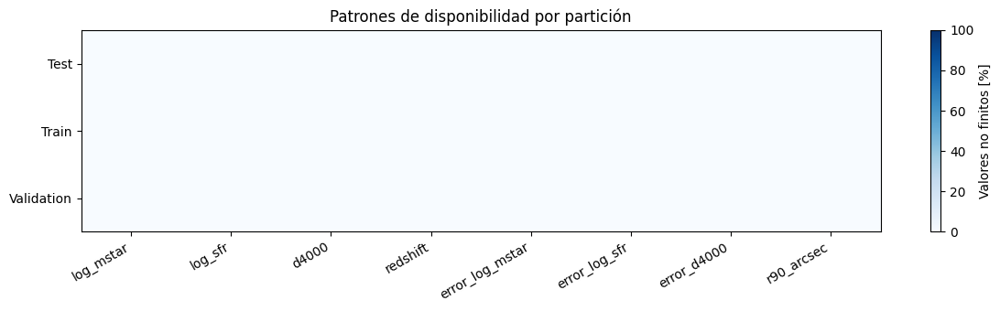

,QCFLAG,categoria,significado,galaxias,porcentaje
0,0,OK,Controles del catálogo superados,9303,96.294379
1,1,BAD,Redshift incorrecto,6,0.062105
2,2,BAD,Baja señal/ruido o campo vacío,0,0.000000
3,3,WARNING,Ajuste y/o AGN intenso,37,0.382983
4,4,WARNING,Masa discrepante con NSA,21,0.217369
5,5,WARNING,Redshift discrepante con NSA,0,0.000000
6,6,WARNING,Estrella en primer plano,207,2.142635
7,7,WARNING,Sistema en fusión,87,0.900528


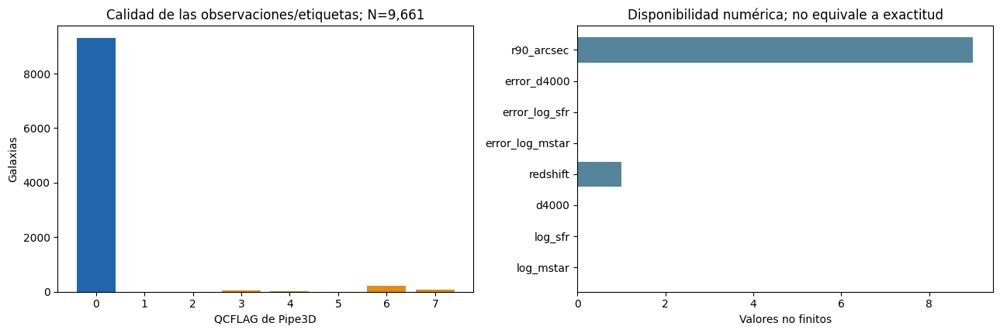

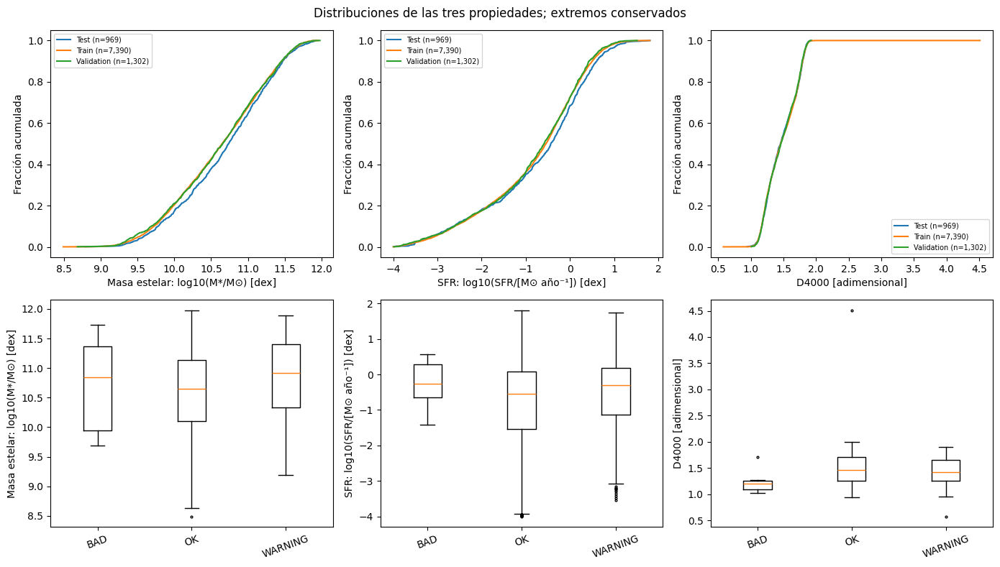

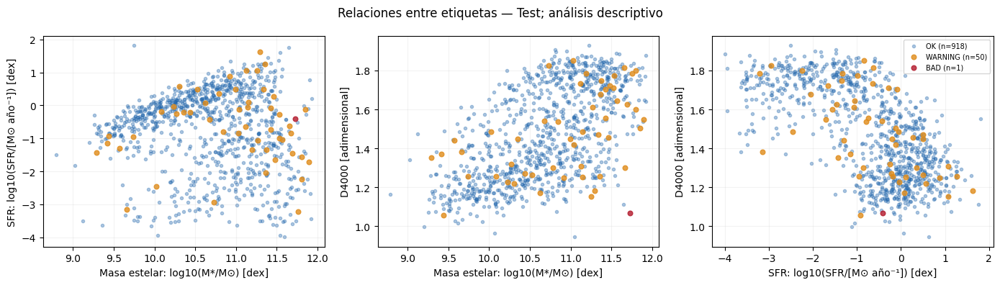

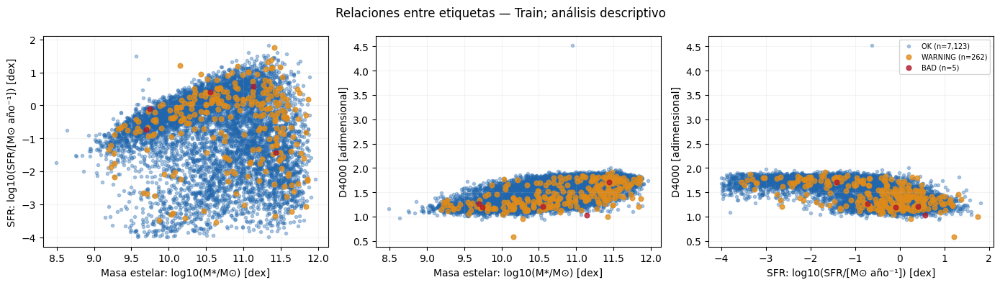

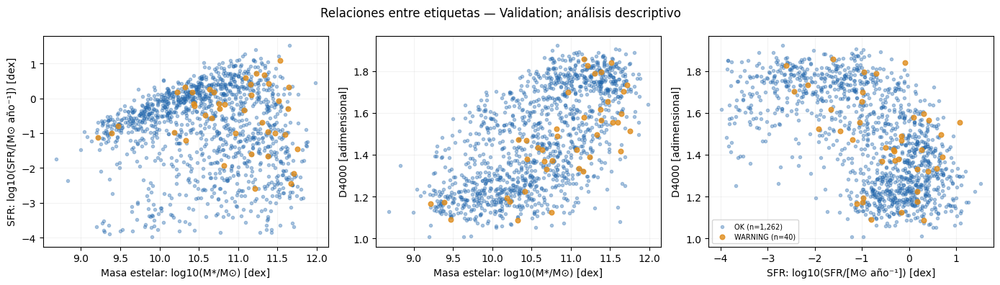

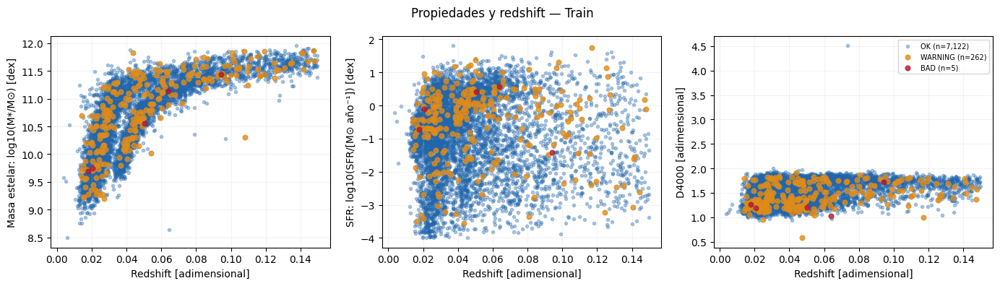

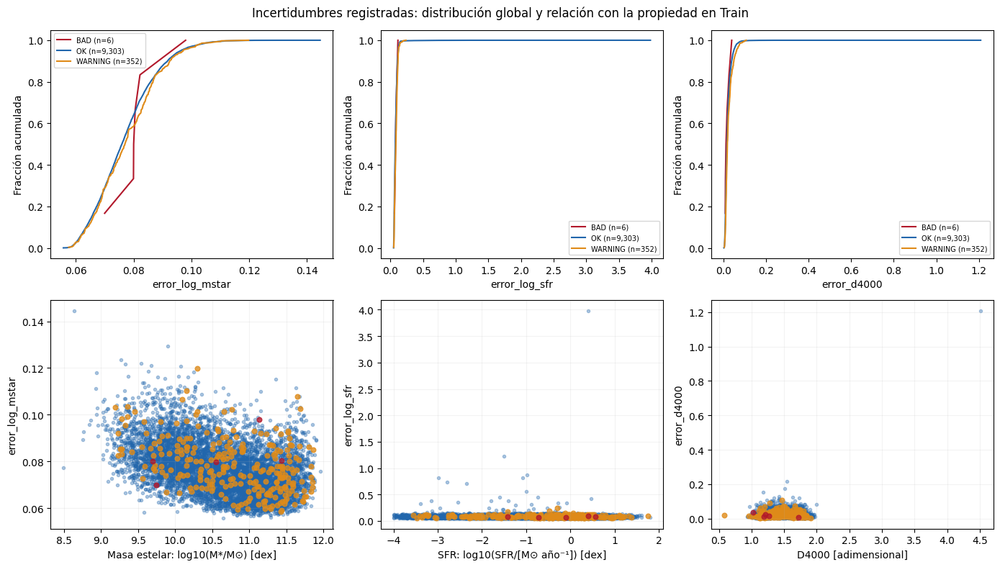

In [15]:
resumen_catalogo = eda_catalogo(catalogo_eda, CARPETA_EDA)


### 7.1. Lectura estadística de las distribuciones y sus ausencias

La gráfica de disponibilidad no muestra valores no finitos en las tres etiquetas objetivo ni en sus incertidumbres; sí identifica un registro no finito en redshift y ausencias en el radio auxiliar. La escala porcentual de 0 a 100 % del mapa de ausencias hace poco visibles los conteos pequeños. Por eso lo interpretamos junto con los conteos, no como prueba visual de completitud absoluta. No atribuimos las ausencias a un mecanismo aleatorio o a una causa física únicamente a partir de su frecuencia.

En una distribución acumulada, una subida pronunciada indica concentración de observaciones en un intervalo estrecho; una cola extendida representa pocos objetos repartidos sobre un rango amplio. Los diagramas de caja permiten situar mediana, cuartiles y puntos alejados del cuerpo principal. Los puntos que quedan fuera de los bigotes son extremos según esa regla descriptiva, **no errores confirmados**.

Las particiones tienen formas generales semejantes, aunque sus curvas no coinciden exactamente, especialmente en masa y SFR. Conservamos esa diferencia como observación descriptiva: no afirmamos equivalencia estadística ni ausencia de sesgos de selección. El extremo alto de D4000 prolonga considerablemente el eje del grupo sin alerta y de Train, de modo que puede ocultar visualmente variaciones dentro del intervalo más poblado.

Utilizamos conjuntamente media y mediana para describir localización, y desviación estándar, IQR y MAD para contextualizar la dispersión. Una diferencia entre media y mediana puede sugerir asimetría, pero no basta para diagnosticar una distribución concreta. En las imágenes, `mad_sigma` corresponde a $1.4826\,\mathrm{mediana}(|x-\mathrm{mediana}(x)|)$; el factor la hace comparable con una desviación estándar bajo una distribución normal ideal, sin suponer que los píxeles reales cumplan ese modelo.

Las etiquetas de masa y SFR ya están en logaritmo decimal. No deducimos que deban transformarse otra vez por presentar colas, ni elegimos una transformación por buscar una forma visualmente normal. Para esta fase mantenemos su significado físico y describimos los rangos escasamente poblados. Al tratarse de regresión, hablamos de **cobertura desigual del espacio de propiedades**, no de desequilibrio de clases objetivo.


### 7.2. Relaciones, incertidumbres y calidad de referencia

Las nubes de puntos muestran estructura entre masa, SFR y D4000, pero también una dispersión amplia: una etiqueta no determina de manera única las otras. En particular, observamos una tendencia visual hacia D4000 menor en la zona de SFR elevada. Esta lectura no establece causalidad ni separa por sí sola los efectos de masa, selección y errores de referencia.

El análisis calcula Pearson y Spearman por pareja y partición. Pearson resume asociación lineal y puede ser sensible a extremos; Spearman compara rangos y resume asociación monótona. Sus valores se conservan en las tablas de resultados, aunque no se imprimen en estas salidas. Por esa razón, no añadimos coeficientes numéricos ni calificamos la fuerza o significación estadística de una correlación sin consultar esos valores. Las correlaciones entre etiquetas tampoco son una medida del desempeño futuro de las imágenes para predecirlas.

La distribución de calidad comprende **9,303 OK (96.29 %), 352 WARNING (3.64 %) y 6 BAD (0.06 %)**, con porcentajes redondeados. Las 358 alertas totales no son 358 WARNING. El grupo BAD es demasiado pequeño para extraer conclusiones estables sobre su distribución a partir de sus cajas o promedios.

Las gráficas de incertidumbre muestran extremos incluso dentro de QCFLAG = 0. En consecuencia, conservamos como dimensiones distintas la alerta del catálogo, el valor de la propiedad y su incertidumbre. Una incertidumbre registrada no resume necesariamente todos los errores sistemáticos; tampoco utilizamos su magnitud como umbral automático de exclusión en este EDA.

El acuerdo de excluir WARNING y BAD del experimento dejaría **7,123 Train, 1,262 Validation y 918 Test**, es decir, 9,303 candidatas antes de resolver los criterios de imagen. Este conteo expresa la consecuencia del acuerdo, no una muestra de entrenamiento ya creada por estas celdas. Para el análisis descriptivo conservamos las 9,661.

Finalmente, redshift se utiliza como contexto observacional. La relación visible entre masa y redshift puede reflejar selección y otras dependencias de la muestra; no la interpretamos como evolución temporal demostrada. No contamos aquí con una serie de observaciones repetidas en el tiempo, por lo que no corresponde un análisis de tendencia temporal convencional. La inspección descriptiva de Test queda documentada y no convierte ese conjunto en completamente ciego.


## 8. Distribuciones de las imágenes y relación con las etiquetas

Separamos la distribución de **todos los píxeles finitos** de la distribución de **estadísticas por imagen**. En la primera, ponderamos por el número de píxeles; en la segunda, cada imagen aporta una observación. Conservamos denominadores explícitos para no confundir una muestra incompleta con el total previsto.

Comparamos las tres bandas, los campos de 800 y 300 píxeles, la disponibilidad por partición y QCFLAG, y los casos que concentran ceros o valores no finitos. También describimos en Train la relación entre las etiquetas y la intensidad media del campo central. Esa intensidad mezcla el objetivo con vecinos y fondo residual: **no es una medida aislada de luminosidad, color o masa**.

Una media mayor puede deberse al tamaño angular, a estrellas cercanas o a artefactos. Un máximo elevado no prueba saturación del detector. Cuando falta cobertura, el resumen sobre píxeles finitos sigue siendo computable, pero su interpretación científica puede estar comprometida. Las tablas y galerías nos permiten examinar estos casos conjuntamente.


In [16]:
def eda_imagenes(cat,audit,stats,general,cfg,out):
    unida=cat.merge(general,on='mangaid',how='left',validate='one_to_one')
    formato_cols=[c for c in ['banda','estado_lectura','alto','ancho','dtype','BUNIT','VERSION'] if c in audit]
    formatos=audit.groupby(formato_cols,dropna=False).size().rename('registros').reset_index()
    guardar_csv(formatos,out/'formatos_encontrados.csv');display(formatos)
    t=stats.merge(cat[['mangaid','particion','grupo_qc',*OBJETIVOS]],on='mangaid',how='left',validate='many_to_one')
    conjuntos=unida.groupby(['particion','grupo_qc','tres_bandas_leidas','forma_grz_esperada'],dropna=False).size().rename('galaxias').reset_index()
    guardar_csv(conjuntos,out/'lectura_por_particion_y_qc.csv');display(conjuntos)
    errores=audit.loc[audit.estado_lectura.ne('Leído')].copy();guardar_csv(errores,out/'incidencias_lectura.csv')
    fig,axs=plt.subplots(1,2,figsize=(12,4.5))
    estados=audit.groupby(['banda','estado_lectura']).size().unstack(fill_value=0)
    estados.plot.bar(stacked=True,ax=axs[0],rot=0);axs[0].set(title='Planos legibles por banda',ylabel='Galaxias')
    for estado,s in unida.groupby('tres_bandas_leidas'):
        ok=np.isfinite(s.RA_Pipe3D)&np.isfinite(s.DEC_Pipe3D)
        axs[1].scatter(s.loc[ok,'RA_Pipe3D'],s.loc[ok,'DEC_Pipe3D'],s=8,alpha=.5,label=f'GRZ leído={estado}: {ok.sum():,}',rasterized=True)
    axs[1].set(xlabel='RA [grados]',ylabel='Dec [grados]',title='Distribución de objetivos y disponibilidad local');axs[1].legend(fontsize=7)
    fig.tight_layout();terminar_figura(fig,out/'07_disponibilidad_imagenes.pdf')
    leer=audit.loc[audit.estado_lectura.eq('Leído')]
    if len(leer):
        fig,axs=plt.subplots(1,3,figsize=(14,4))
        for b,s in leer.groupby('banda'):
            for ax,c in zip(axs,['escala_x_arcsec','descentrado_objetivo_pix','diferencia_wcs_g_arcsec']):
                if c in s:ecdf(ax,s[c],b)
        for ax,c in zip(axs,['Escala WCS X [arcsec/píxel]','Distancia al centro de la coordenada solicitada [px]','Diferencia WCS con g [arcsec]']):
            ax.set(xlabel=c,ylabel='Fracción acumulada');ax.legend(fontsize=8)
        fig.suptitle('Geometría instrumental; la coordenada solicitada no es un centro fotométrico medido')
        fig.tight_layout();terminar_figura(fig,out/'08_wcs.pdf')
    if not len(stats):print('Sin imágenes legibles: el EDA de píxeles queda pendiente.');return unida,t
    res=[];globales=[]
    metrics=['media','mediana','std','mad_sigma','porcentaje_cero','porcentaje_negativo','porcentaje_no_finito']
    for (region,b),s in stats.groupby(['region','banda']):
        for c in metrics:
            if c in s:res.append({'region':region,'banda':b,'estadistica_por_imagen':c,**resumen(s[c])})
        n=s.pixeles_finitos.sum();media=np.sum(s.media.fillna(0)*s.pixeles_finitos)/n if n else np.nan
        var=np.sum(s.pixeles_finitos*(s['std'].fillna(0)**2+(s.media.fillna(0)-media)**2))/n if n else np.nan
        globales.append({'region':region,'banda':b,'imagenes':len(s),'pixeles_totales':int(s.pixeles_totales.sum()),
          'pixeles_finitos':int(n),'pixeles_nan':int(s.pixeles_nan.sum()),'pixeles_inf':int(s.pixeles_inf.sum()),
          'media_todos_pixeles_finitos':media,'std_todos_pixeles_finitos':np.sqrt(var),
          'porcentaje_ceros_finitos':100*s.pixeles_cero.sum()/n if n else np.nan,
          'porcentaje_negativos_finitos':100*s.pixeles_negativos.sum()/n if n else np.nan})
    guardar_csv(pd.DataFrame(res),out/'distribuciones_estadisticas_imagenes.csv')
    guardar_csv(pd.DataFrame(globales),out/'resumen_global_pixeles.csv');display(pd.DataFrame(globales))
    for region,s in stats.groupby('region'):
        fig,axs=plt.subplots(2,3,figsize=(14,8))
        for ax,c in zip(axs.flat,metrics[:6]):
            for b,u_ in s.groupby('banda'):ecdf(ax,u_[c],b)
            ax.set(xlabel=c,ylabel='Fracción acumulada');ax.legend(fontsize=7)
        fig.suptitle(f'Estadísticas por imagen — {region}; unidades de píxel según el FITS/producto')
        fig.tight_layout();terminar_figura(fig,out/f'09_estadisticas_{region}.pdf')
    if {'original','central300'}.issubset(set(stats.region)):
        pares=stats.loc[stats.region.eq('original')].merge(stats.loc[stats.region.eq('central300')],on=['mangaid','banda'],suffixes=('_800','_300'),validate='one_to_one')
        guardar_csv(pares,out/'comparacion_estadisticas_800_300.csv')
        fig,axs=plt.subplots(1,3,figsize=(14,4))
        for ax,c in zip(axs,['media','porcentaje_cero','porcentaje_negativo']):
            for b,s in pares.groupby('banda'):ax.scatter(s[c+'_800'],s[c+'_300'],s=8,alpha=.3,label=b,rasterized=True)
            ax.set(xlabel=c+' — 800',ylabel=c+' — 300');ax.legend()
        fig.suptitle('Mismos píxeles centrales a escala nativa; comparamos campos, no flujo total de la galaxia')
        fig.tight_layout();terminar_figura(fig,out/'10_campos_800_300.pdf')
    # Relaciones descriptivas en Train; no interpretamos las medias de campo como fotometría de la galaxia.
    train=t.loc[t.particion.eq('Train')&t.region.eq('central300')]
    if len(train):
        fig,axs=plt.subplots(3,3,figsize=(14,11));corr=[]
        for i,b in enumerate(BANDAS):
            s=train.loc[train.banda.eq(b)]
            for j,c in enumerate(OBJETIVOS):
                disp_qc(axs[i,j],s,c,'media');axs[i,j].set_ylabel(f'Media de píxeles del campo central — {b}')
                v=s[[c,'media']].replace([np.inf,-np.inf],np.nan).dropna()
                corr.append({'banda':b,'propiedad':c,'pares_finitos':len(v),'spearman':v[c].corr(v.media,method='spearman')})
        axs[0,-1].legend(fontsize=7);fig.suptitle('Train: etiquetas e intensidad media del campo; incluye vecinos y fondo residual')
        fig.tight_layout();terminar_figura(fig,out/'11_imagenes_etiquetas_train.pdf')
        guardar_csv(pd.DataFrame(corr),out/'correlaciones_intensidad_etiquetas_train.csv')
    # Sesgo de disponibilidad: describimos, sin convertirlo en regla de selección.
    if unida.tres_bandas_leidas.nunique()>1:
        fig,axs=plt.subplots(1,3,figsize=(14,4))
        for ax,c in zip(axs,OBJETIVOS):
            for g,s in unida.groupby('tres_bandas_leidas'):ecdf(ax,s[c],f'GRZ leído={g}')
            ax.set(xlabel=NOMBRES[c],ylabel='Fracción acumulada');ax.legend(fontsize=7)
        fig.tight_layout();terminar_figura(fig,out/'12_disponibilidad_y_propiedades.pdf')
    for c in ['porcentaje_cero','porcentaje_no_finito','maximo','mad_sigma']:
        top=stats.sort_values(c,ascending=False).groupby(['banda','region'],sort=False).head(5)
        guardar_csv(top,out/f'casos_destacados_{c}.csv')
    if 'porcentaje_soporte_mapa' in audit:
        fig,ax=plt.subplots(figsize=(9,4.5))
        for b,s in audit.groupby('banda'):ecdf(ax,s.porcentaje_soporte_mapa,b)
        ax.set(xlabel='Píxeles con soporte del mapa [%]',ylabel='Fracción acumulada',title='Cobertura: solo mapas presentes y alineados');ax.legend()
        terminar_figura(fig,out/'13_soporte_mapas.pdf')
    return unida,t


,banda,estado_lectura,alto,ancho,dtype,BUNIT,VERSION,registros
0,g,Leído,800,800,>f4,No declarada,DR10,9661
1,r,Leído,800,800,>f4,No declarada,DR10,9661
2,z,Leído,800,800,>f4,No declarada,DR10,9661


,particion,grupo_qc,tres_bandas_leidas,forma_grz_esperada,galaxias
0,Test,BAD,True,True,1
1,Test,OK,True,True,918
2,Test,WARNING,True,True,50
3,Train,BAD,True,True,5
4,Train,OK,True,True,7123
5,Train,WARNING,True,True,262
6,Validation,OK,True,True,1262
7,Validation,WARNING,True,True,40


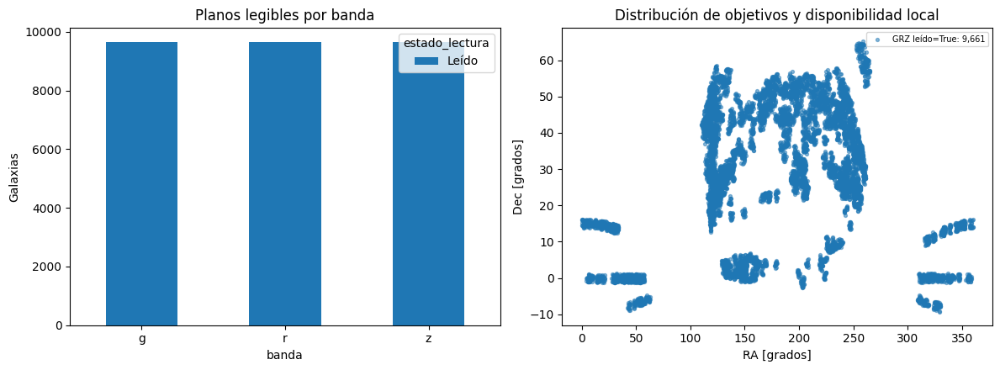

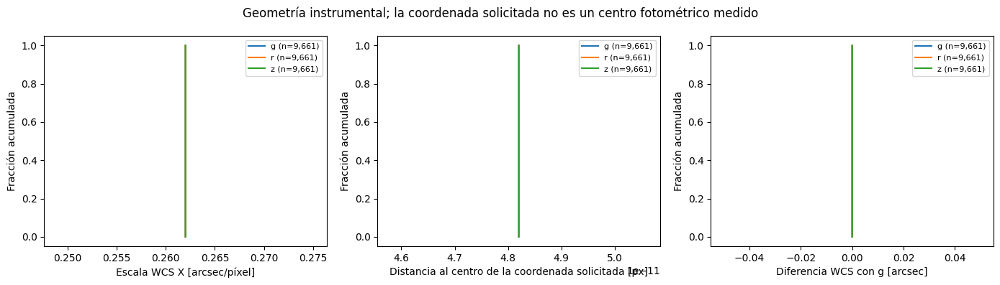

,region,banda,imagenes,pixeles_totales,pixeles_finitos,pixeles_nan,pixeles_inf,media_todos_pixeles_finitos,std_todos_pixeles_finitos,porcentaje_ceros_finitos,porcentaje_negativos_finitos
0,central300,g,9661,869490000,869490000,0,0,0.012765,0.242289,0.030116,32.443522
1,central300,r,9661,869490000,869490000,0,0,0.021332,0.290594,0.028440,31.912203
2,central300,z,9661,869490000,869490000,0,0,0.028456,0.307236,0.061245,38.046388
3,original,g,9661,6183040000,6183040000,0,0,0.009839,0.279469,0.041965,43.179717
4,original,r,9661,6183040000,6183040000,0,0,0.014072,0.326954,0.035059,42.905062
5,original,z,9661,6183040000,6183040000,0,0,0.014920,0.306405,0.059678,45.125234


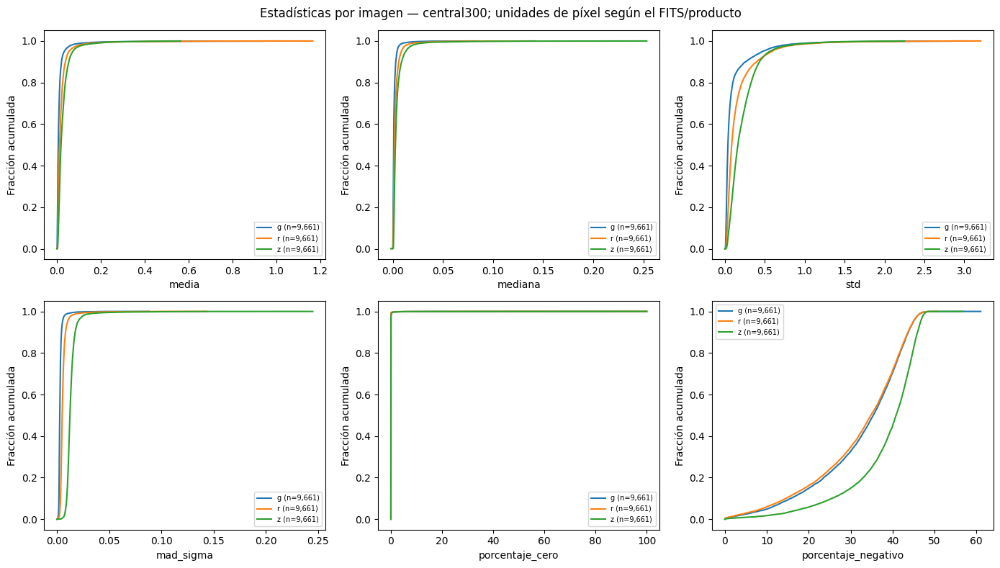

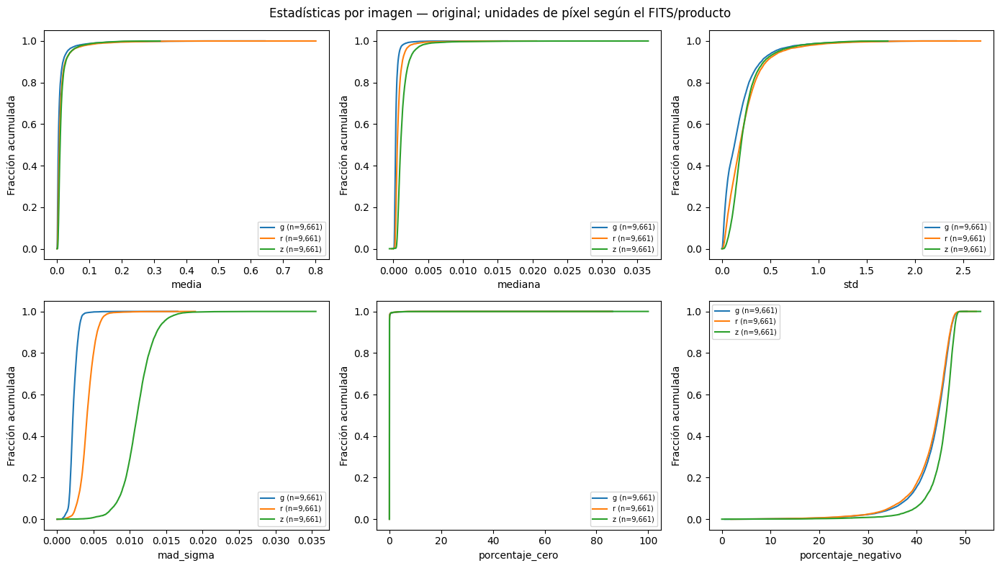

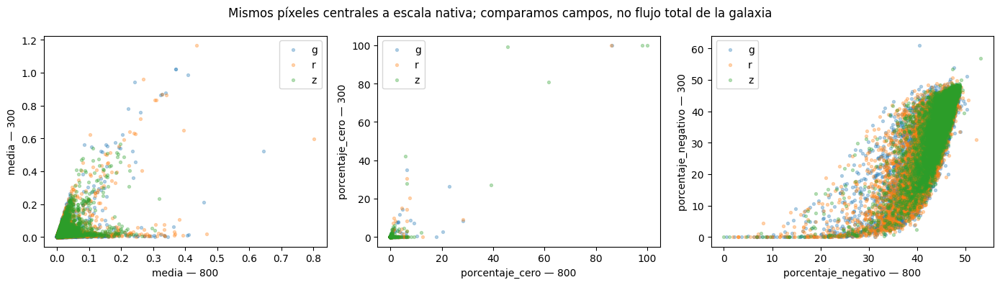

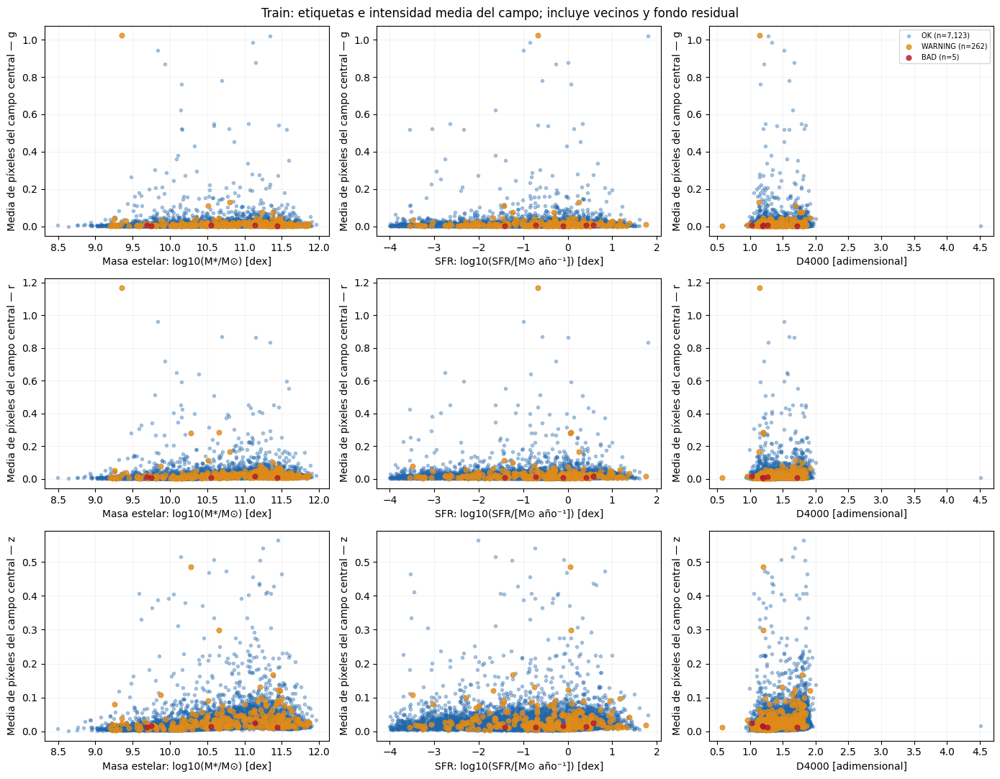

In [17]:
catalogo_con_lectura, estadisticas_integradas = eda_imagenes(catalogo_eda, auditoria_fits, estadisticas_fits, lectura_galaxias, CFG, CARPETA_EDA)


### 8.1. Interpretación de las estadísticas de imagen

Los planos originales son de tipo flotante de 32 bits (`>f4`) y declaran DR10; `BUNIT` aparece como **«No declarada»**. Los conteos por banda incluyen 6,183,040,000 píxeles en el campo original y 869,490,000 en el centro. Los seis conjuntos banda–región contienen únicamente valores finitos.

| Banda | Media de píxeles: 800 × 800 | Media de píxeles: 300 × 300 | Negativos en 800 × 800 | Negativos en 300 × 300 |
|---|---:|---:|---:|---:|
| g | 0.009839 | 0.012765 | 43.18 % | 32.44 % |
| r | 0.014072 | 0.021332 | 42.91 % | 31.91 % |
| z | 0.014920 | 0.028456 | 45.13 % | 38.05 % |

Estas medias, transcritas de la salida anterior, se expresan en los valores almacenados del producto; no les asignamos una unidad física no verificada. La región central tiene mayor media global en las tres bandas y menor proporción de valores negativos. El resultado es compatible con una mayor concentración de señal positiva hacia el centro, pero no demuestra que cada galaxia esté bien centrada ni que el cambio de campo preserve su flujo.

La comparación de porcentajes de ceros tampoco es uniforme: disminuye al pasar al centro en g y r, pero aumenta ligeramente en z. Un promedio de toda la población puede ocultar unos pocos campos con incidencias extensas. Por ello, lo complementamos con distribuciones por imagen y máscaras espaciales.

En los campos originales, **2,737 de 28,983 planos (9.44 %)** contienen al menos un cero. Este porcentaje mide presencia de ceros por plano; no es el porcentaje de píxeles nulos ni el porcentaje de galaxias inutilizables. Los ceros son valores finitos y deben distinguirse de NaN e infinitos. Los negativos tampoco se clasifican automáticamente como defectos.

Las relaciones de intensidad media central con las etiquetas muestran una concentración de puntos a intensidades bajas y casos separados hacia valores elevados. Como el descriptor incluye vecinos y fondo residual, no lo denominamos luminosidad de la galaxia ni lo usamos para decidir qué banda contiene más información física. Tampoco interpretamos diferencias entre las bandas como colores calibrados sin verificar la definición del producto y la medición correspondiente.


## 9. Tamaño angular y campo disponible

Usamos los radios NSA en arcsec. Primero comparamos el diámetro $D_{90}$ con el lado nominal de cada campo, asumiendo centrado. Después incorporamos la posición proyectada de la coordenada objetivo para estimar el margen respecto al borde más cercano en cada banda.

La segunda comparación es una **aproximación local de la geometría WCS**, apropiada como diagnóstico de estos recortes pequeños y sus rejillas usuales; no reemplaza una medición de isofotas. Tampoco trasladamos literalmente a DESI la fracción de flujo con la que se definió el radio en su catálogo de origen. Que D90 quepa no significa que toda la galaxia ni sus regiones exteriores estén contenidas o libres de vecinos.

El análisis completo determinará cuántas candidatas exceden el campo. Los resultados previos de 291/300 dentro del campo de 300 píxeles fueron específicos de aquella muestra provisional; **no se incorporan como resultados del catálogo completo**.


In [18]:
def geometria(cat,audit,cfg,out):
    t=cat.copy();nominal=[]
    for lado in [cfg['lado_recorte'],cfg['lado_original']]:
        campo=lado*cfg['escala_arcsec_pixel'];util=t.radio_utilizable
        dentro=util&t.d90_arcsec.le(campo)
        t[f'd90_cabe_nominal_{lado}']=pd.Series(pd.NA,index=t.index,dtype='boolean');t.loc[util,f'd90_cabe_nominal_{lado}']=dentro[util]
        nominal.append({'lado_pixeles':lado,'campo_arcsec':campo,'radios_utilizables':int(util.sum()),
                        'd90_no_supera_campo':int(dentro.sum()),'d90_supera_campo':int((util&~dentro).sum()),
                        'sin_radio_utilizable':int((~util).sum())})
    por_id=t.set_index('mangaid')
    # Un círculo de R90 solo se compara con una rejilla local ortogonal; no se ajusta la forma de la galaxia.
    real=[]
    for _,r in audit.loc[audit.estado_lectura.eq('Leído')].iterrows():
        g=por_id.loc[r.mangaid]
        for lado in [cfg['lado_recorte'],cfg['lado_original']]:
            fila={'mangaid':r.mangaid,'banda':r.banda,'lado_pixeles':lado,'estado':'No evaluable','margen_r90_arcsec':np.nan}
            vals=[r.get('objetivo_x_pix'),r.get('objetivo_y_pix'),r.get('escala_x_arcsec'),r.get('escala_y_arcsec')]
            if g.radio_utilizable and all(v is not None and np.isfinite(v) for v in vals) and r.get('forma_esperada',False):
                x,y,sx,sy=vals;ini=(cfg['lado_original']-lado)//2
                distancia=min((x-ini+.5)*sx,(ini+lado-.5-x)*sx,(y-ini+.5)*sy,(ini+lado-.5-y)*sy)
                margen=distancia-g.r90_arcsec
                fila.update(estado='Cabe en aproximación local' if margen>=0 else 'Supera un borde en aproximación local',margen_r90_arcsec=margen)
            real.append(fila)
    guardar_csv(pd.DataFrame(nominal),out/'comparacion_nominal_d90.csv')
    guardar_csv(pd.DataFrame(real),out/'comparacion_r90_con_posicion_wcs.csv')
    guardar_csv(t,out/'catalogo_con_geometria.csv');display(pd.DataFrame(nominal))
    valid=t.loc[t.radio_utilizable]
    if len(valid):
        fig,axs=plt.subplots(1,2,figsize=(12,4.5))
        for g,s in valid.groupby('particion'):ecdf(axs[0],s.d90_arcsec,g)
        for lado,color in [(cfg['lado_recorte'],'#b2182b'),(cfg['lado_original'],'#2166ac')]:
            axs[0].axvline(lado*cfg['escala_arcsec_pixel'],color=color,ls='--',label=f'{lado}px')
        axs[0].set(xlabel='D90 NSA [arcsec]',ylabel='Fracción acumulada');axs[0].legend(fontsize=7)
        if 'redshift' in valid:disp_qc(axs[1],valid.loc[valid.particion.eq('Train')],'redshift','d90_arcsec')
        axs[1].axhline(cfg['lado_recorte']*cfg['escala_arcsec_pixel'],color='#b2182b',ls='--');axs[1].set_ylabel('D90 NSA [arcsec]')
        fig.suptitle('Comparación geométrica con R90; no certifica retención de flujo ni ausencia de vecinos')
        fig.tight_layout();terminar_figura(fig,out/'14_tamanos_angulares.pdf')
    else:print('Sin radios utilizables: se omiten las gráficas de Petro90, sin detener el resto del EDA.')
    return t


,lado_pixeles,campo_arcsec,radios_utilizables,d90_no_supera_campo,d90_supera_campo,sin_radio_utilizable
0,300,78.6,9652,9439,213,9
1,800,209.6,9652,9645,7,9


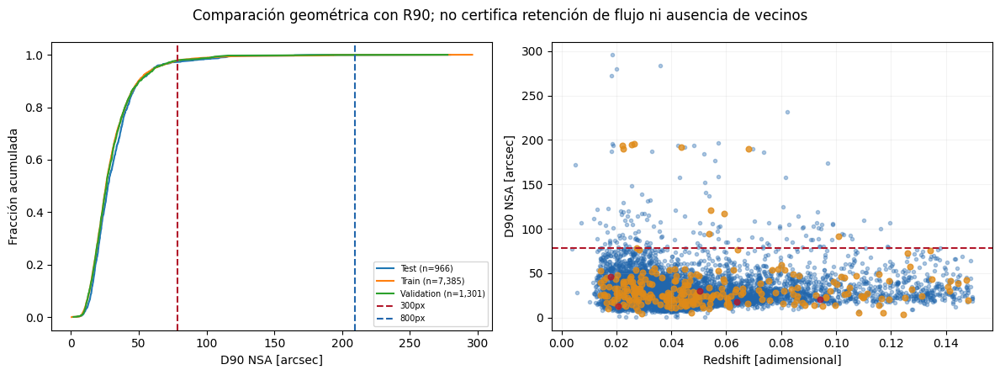

In [19]:
catalogo_geometria = geometria(catalogo_eda, auditoria_fits, CFG, CARPETA_EDA)


### 9.1. Resultado geométrico y alcance de Petro90

| Campo | Lado angular | D90 no supera el lado | D90 supera el lado | Denominador con radio válido |
|---|---:|---:|---:|---:|
| Centro de 300 × 300 | 78.6 arcsec | 9,439 (97.79 %) | 213 (2.21 %) | 9,652 |
| Original de 800 × 800 | 209.6 arcsec | 9,645 (99.93 %) | 7 (0.073 %) | 9,652 |

Los porcentajes utilizan exclusivamente los 9,652 radios finitos y positivos. Las nueve candidatas restantes no se cuentan como «dentro» ni «fuera». Los siete objetos que superan el lado del campo original pertenecen también al grupo que supera el campo central; **no sumamos ambos conteos**.

Esta evidencia muestra que el campo de 300 píxeles abarca nominalmente D90 para la mayoría, pero no para todas las candidatas. También descarta garantizar que el campo de 800 píxeles abarque ese diámetro en todos los casos. Ninguno de estos conteos mide cuánta luz falta: Petro90 conserva la definición fotométrica de NSA y no equivale a una frontera exacta de la galaxia en las tres bandas DESI.

Como decisión descriptiva provisional, mantenemos estas comparaciones como **indicadores para revisión**, sin excluir objetos por tamaño ni estimar una pérdida de flujo mediante la proporción de áreas. Un radio aparentemente incompatible con la imagen motiva revisar asociación, definición y calidad de la medida; no lo sustituimos por una estimación visual.


## 10. Galerías comparables y casos de interés

Mostramos la banda r del campo completo y del centro de 300 píxeles, manteniendo exactamente la misma escala de visualización en cada pareja. El estiramiento asinh y los percentiles afectan únicamente a la representación. La escala de la pantalla puede ampliar el centro, pero la muestra numérica conserva los píxeles originales.

Incluimos ejemplos generales, galaxias cuyo D90 supera el campo de 300 píxeles, ejemplos que no lo superan, casos WARNING/BAD disponibles y los mayores porcentajes de ceros o no finitos. Guardamos los identificadores y el criterio de selección. Por defecto elegimos ejemplos de Train; una galería de seis casos no sustituye una revisión de toda la muestra.

Una galería adicional muestra g/r/z por separado y localiza ceros y no finitos. No aplicamos esas representaciones como máscaras a los datos. Las escalas visuales independientes entre bandas **no permiten inferir colores fotométricos**.


In [20]:
def norma_visual(a,cfg):
    v=a[np.isfinite(a)]
    if not len(v):return ImageNormalize(vmin=0,vmax=1,stretch=AsinhStretch(cfg['asinh_visualizacion']))
    lo,hi=np.percentile(v,cfg['percentiles_visualizacion'])
    if hi<=lo:lo,hi=float(v.min()),float(v.max())
    if hi<=lo:hi=lo+1
    return ImageNormalize(vmin=lo,vmax=hi,stretch=AsinhStretch(cfg['asinh_visualizacion']),clip=True)

def elegir_galerias(inv,geo,stats,general,cfg,out):
    base=geo.loc[geo.particion.isin(cfg['particiones_galerias'])].merge(general[['mangaid','tres_bandas_leidas','forma_grz_esperada']],on='mangaid',validate='one_to_one')
    base=base.loc[base.tres_bandas_leidas&base.forma_grz_esperada].copy()
    n=cfg['n_ejemplos_por_galeria'];selecciones=[]
    def agregar(nombre,t,metodo):
        if len(t):selecciones.append(t[['mangaid','particion','grupo_qc','r90_arcsec','d90_arcsec']].assign(galeria=nombre,seleccion=metodo))
    agregar('muestra_general',base.sample(min(n,len(base)),random_state=cfg['semilla_galerias']),'Aleatoria reproducible; no representa todos los casos')
    conradio=base.loc[base.radio_utilizable]
    agregar('d90_supera_300',conradio.loc[conradio.d90_arcsec.gt(cfg['lado_recorte']*cfg['escala_arcsec_pixel'])].nlargest(n,'d90_arcsec'),'Mayores diámetros que superan el campo')
    cabe=conradio.loc[conradio.d90_arcsec.le(cfg['lado_recorte']*cfg['escala_arcsec_pixel'])].sort_values('d90_arcsec')
    if len(cabe):agregar('d90_no_supera_300',cabe.iloc[np.unique(np.linspace(0,len(cabe)-1,min(n,len(cabe))).round().astype(int))],'Posiciones espaciadas en el orden de diámetros')
    for grupo in ['WARNING','BAD']:
        s=base.loc[base.grupo_qc.eq(grupo)]
        agregar('qc_'+grupo.lower(),s.sample(min(n,len(s)),random_state=cfg['semilla_galerias']),'Ejemplos para revisión; decisión de uso conservada')
    if len(stats):
        for c in ['porcentaje_cero','porcentaje_no_finito']:
            ranking=stats.loc[stats.region.eq('original')].groupby('mangaid')[c].max().sort_values(ascending=False)
            ids=ranking.loc[(ranking>0)&ranking.index.isin(base.mangaid)].head(n).index
            agregar(c,base.set_index('mangaid').reindex(ids).reset_index(),'Mayores porcentajes detectados, sin umbral de exclusión')
    agregar('solicitadas',base.loc[base.mangaid.isin(cfg['ids_galeria_adicional'])],'Identificadores indicados por el usuario')
    sel=pd.concat(selecciones,ignore_index=True) if selecciones else pd.DataFrame(columns=['mangaid','galeria'])
    guardar_csv(sel,out/'seleccion_galerias.csv')
    display(sel.groupby('galeria').size().rename('ejemplos').reset_index())
    return sel

def generar_galerias(sel,inv,cfg,out):
    lookup=inv.set_index('mangaid',drop=False);b='r'
    for nombre,seleccion in sel.groupby('galeria',sort=False):
        p=out/f'15_galeria_{nombre}.pdf'
        with PdfPages(p) as pdf:
            for inicio in range(0,len(seleccion),3):
                bloque=seleccion.iloc[inicio:inicio+3];fig,axs=plt.subplots(len(bloque),2,figsize=(10,4*len(bloque)),squeeze=False)
                for i,(_,s) in enumerate(bloque.iterrows()):
                    fila=lookup.loc[s.mangaid].to_dict();datos,hs,_,_=leer_bandas(fila,cfg)
                    if b not in datos:
                        for ax in axs[i]:ax.text(.5,.5,'Imagen no disponible',ha='center',transform=ax.transAxes)
                        continue
                    a=datos[b];norm=norma_visual(a,cfg);alto,ancho=a.shape
                    ini=(cfg['lado_original']-cfg['lado_recorte'])//2;fin=ini+cfg['lado_recorte']
                    for j,sub in enumerate([a,a[ini:fin,ini:fin]]):
                        cmap=plt.colormaps['gray'].copy();cmap.set_bad('#f000bd')
                        axs[i,j].imshow(np.ma.masked_invalid(sub),origin='lower',cmap=cmap,norm=norm,interpolation='nearest')
                        axs[i,j].set_xlabel('Píxeles del FITS');axs[i,j].set_ylabel('Píxeles')
                    axs[i,0].add_patch(Rectangle((ini-.5,ini-.5),cfg['lado_recorte'],cfg['lado_recorte'],fill=False,color='#ffc857',lw=1))
                    winfo,_=informacion_wcs(hs[b],a,fila,cfg)
                    if np.isfinite(s.r90_arcsec) and s.r90_arcsec>0 and np.isfinite(winfo['objetivo_x_pix']):
                        for j,ax in enumerate(axs[i]):
                            off=0 if j==0 else ini
                            ax.add_patch(Ellipse((winfo['objetivo_x_pix']-off,winfo['objetivo_y_pix']-off),
                                2*s.r90_arcsec/winfo['escala_x_arcsec'],2*s.r90_arcsec/winfo['escala_y_arcsec'],
                                fill=False,edgecolor='#32c5d2',lw=.8))
                    escala=winfo['escala_x_arcsec']
                    escala_txt=f'{escala:.3f}″/px' if np.isfinite(escala) else 'escala sin confirmar'
                    axs[i,0].set_title(f'{s.mangaid} | {s.grupo_qc} | r, 800 × 800 | {escala_txt}',fontsize=9)
                    radio=f'{s.d90_arcsec:.2f}″' if np.isfinite(s.d90_arcsec) else 'no disponible'
                    axs[i,1].set_title(f'Centro 300 × 300 | D90={radio}',fontsize=10)
                fig.suptitle(nombre+'\nMisma escala de visualización por pareja; amarillo: recorte, cian: R90',fontsize=12)
                fig.tight_layout(rect=[0,0,1,.95]);pdf.savefig(fig);plt.show();plt.close(fig)
        registrar_pdf(p)
    # Bandas separadas para detectar problemas que una imagen RGB podría ocultar.
    ids=sel.loc[sel.galeria.eq('porcentaje_cero'),'mangaid'].tolist()[:3]
    if not ids:ids=sel.mangaid.drop_duplicates().head(3).tolist()
    if ids:
        p=out/'16_galeria_bandas_y_ceros.pdf'
        with PdfPages(p) as pdf:
            for g in ids:
                a,hs,_,_=leer_bandas(lookup.loc[g].to_dict(),cfg);fig,axs=plt.subplots(2,3,figsize=(12,8))
                for j,b in enumerate(BANDAS):
                    if b not in a:continue
                    axs[0,j].imshow(np.ma.masked_invalid(a[b]),origin='lower',cmap='gray',norm=norma_visual(a[b],cfg))
                    cod=np.zeros(a[b].shape,dtype=np.uint8);cod[a[b]==0]=1;cod[~np.isfinite(a[b])]=2
                    from matplotlib.colors import ListedColormap,BoundaryNorm
                    axs[1,j].imshow(cod,origin='lower',cmap=ListedColormap(['#191919','#ffc857','#ef31b0']),norm=BoundaryNorm([-.5,.5,1.5,2.5],3),interpolation='nearest')
                    axs[0,j].set_title(f'{g} — {b}');axs[1,j].set_title('Amarillo: cero; magenta: no finito',fontsize=9)
                fig.suptitle('Escalas de visualización independientes entre bandas; no es una medida de color')
                fig.tight_layout();pdf.savefig(fig);plt.show();plt.close(fig)
        registrar_pdf(p)


,galeria,ejemplos
0,d90_no_supera_300,6
1,d90_supera_300,6
2,muestra_general,6
3,porcentaje_cero,6
4,qc_bad,5
5,qc_warning,6
6,solicitadas,2


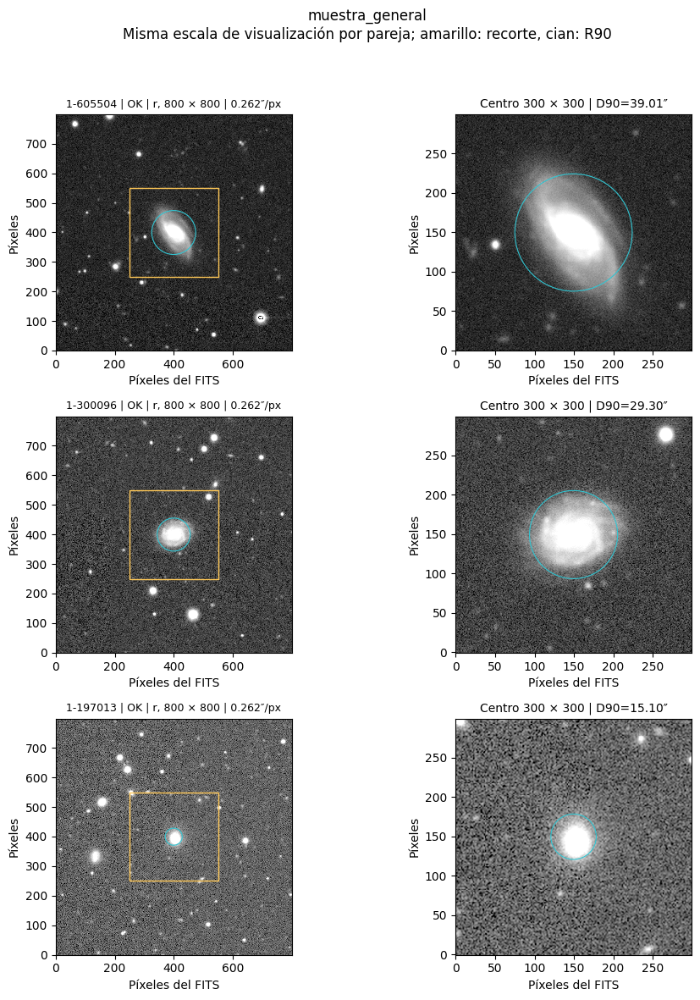

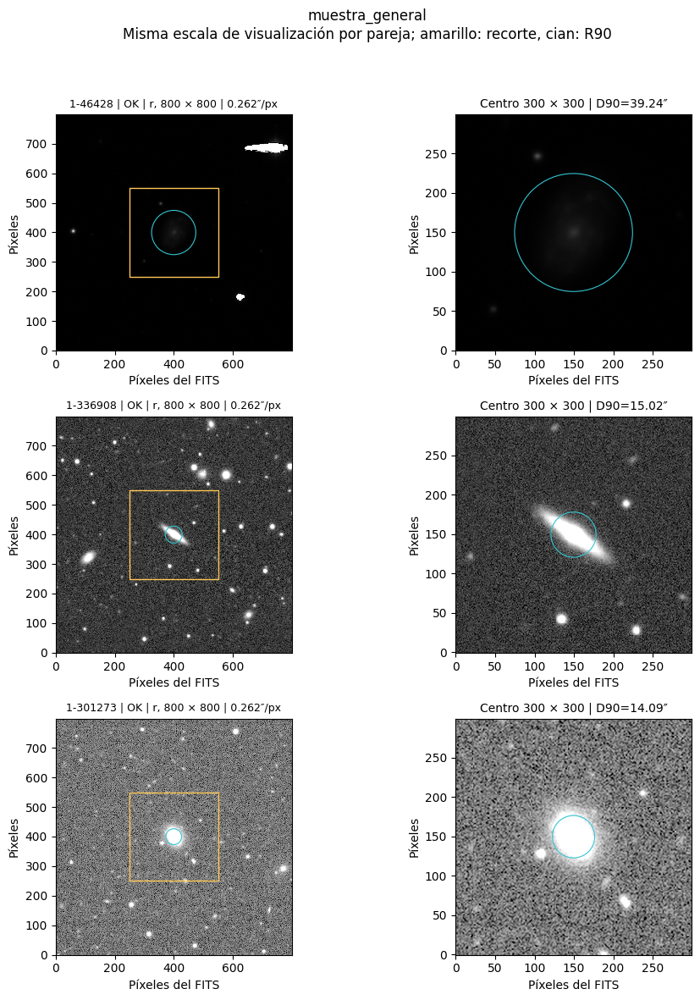

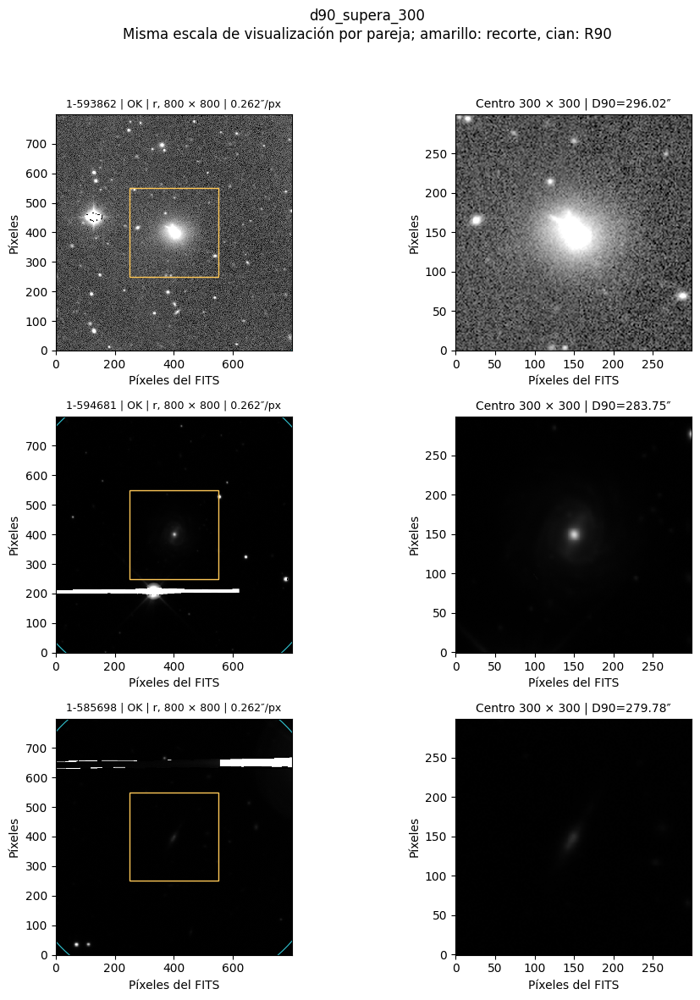

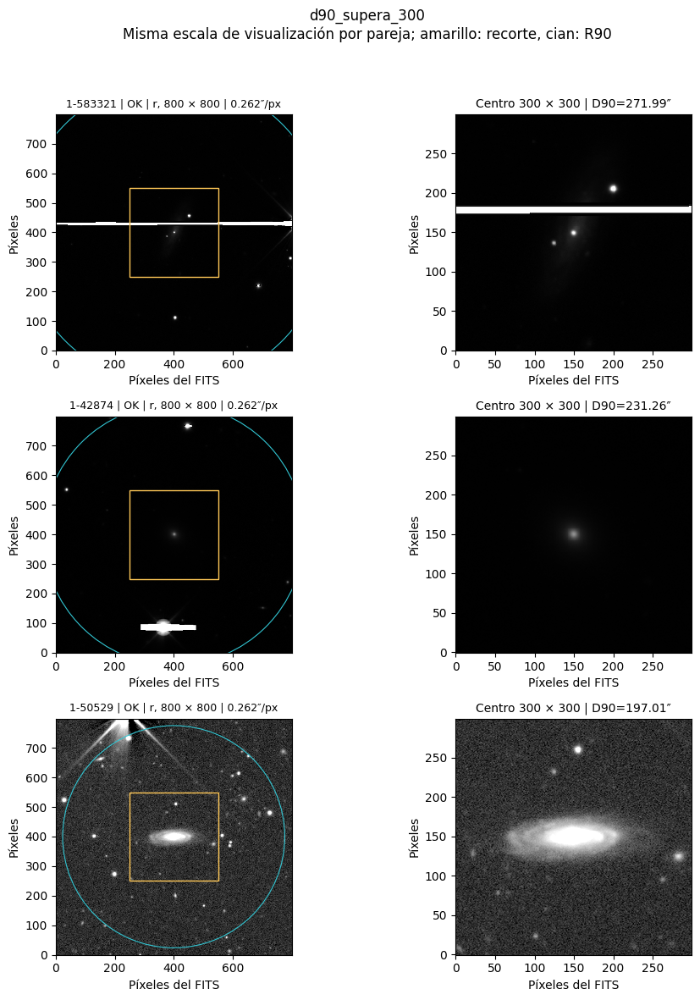

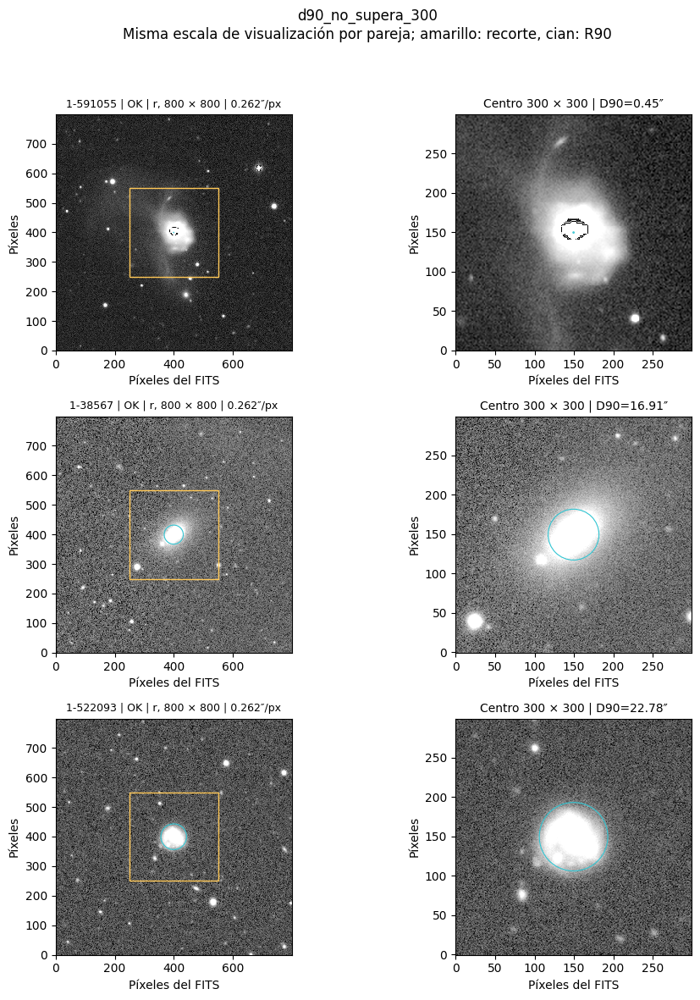

...

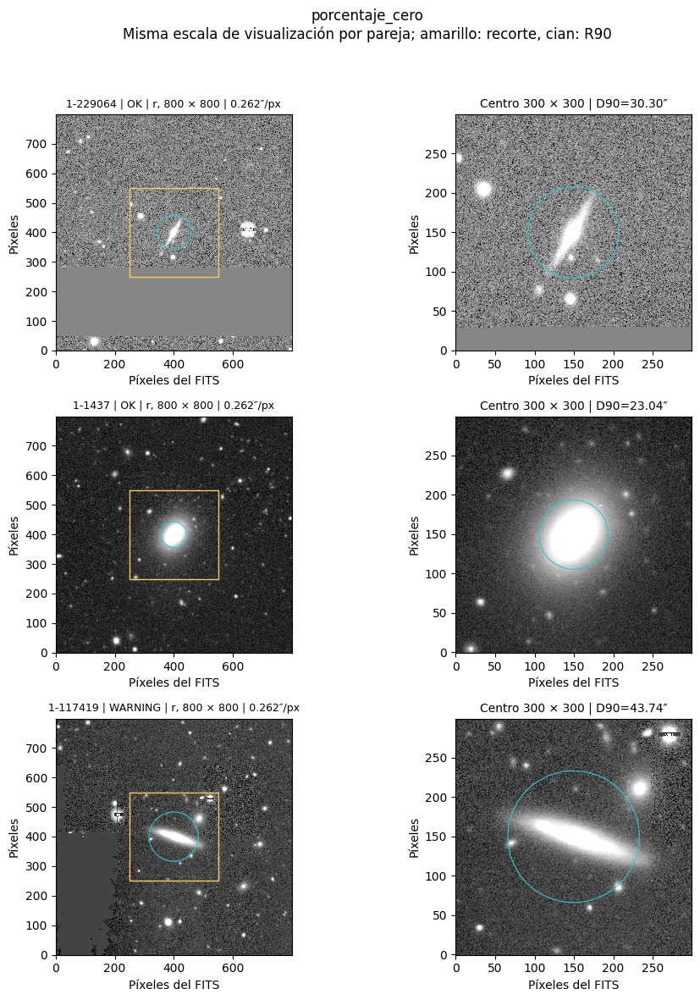

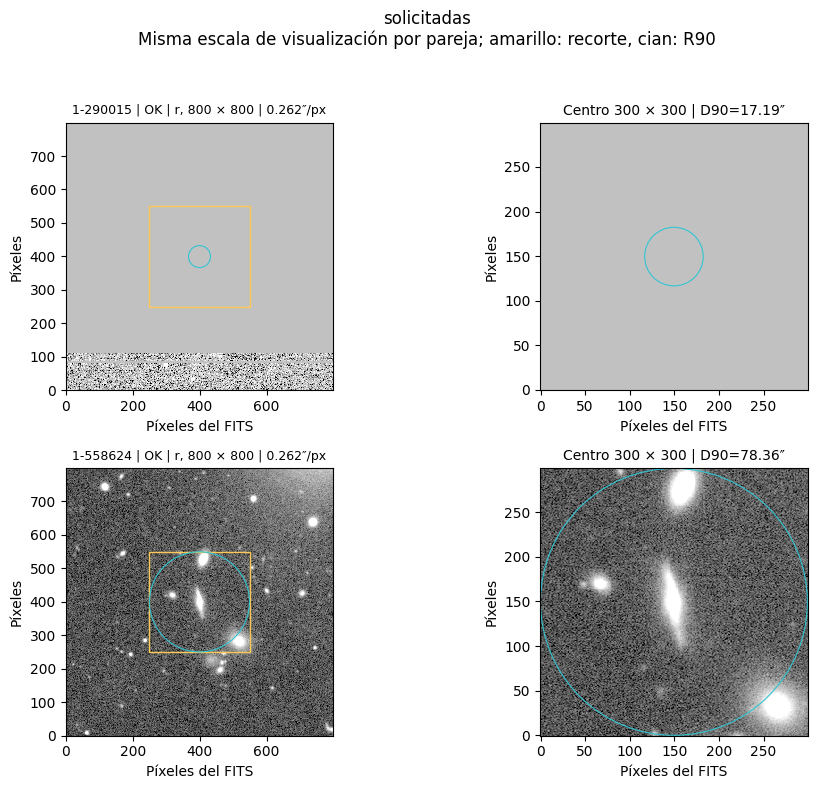

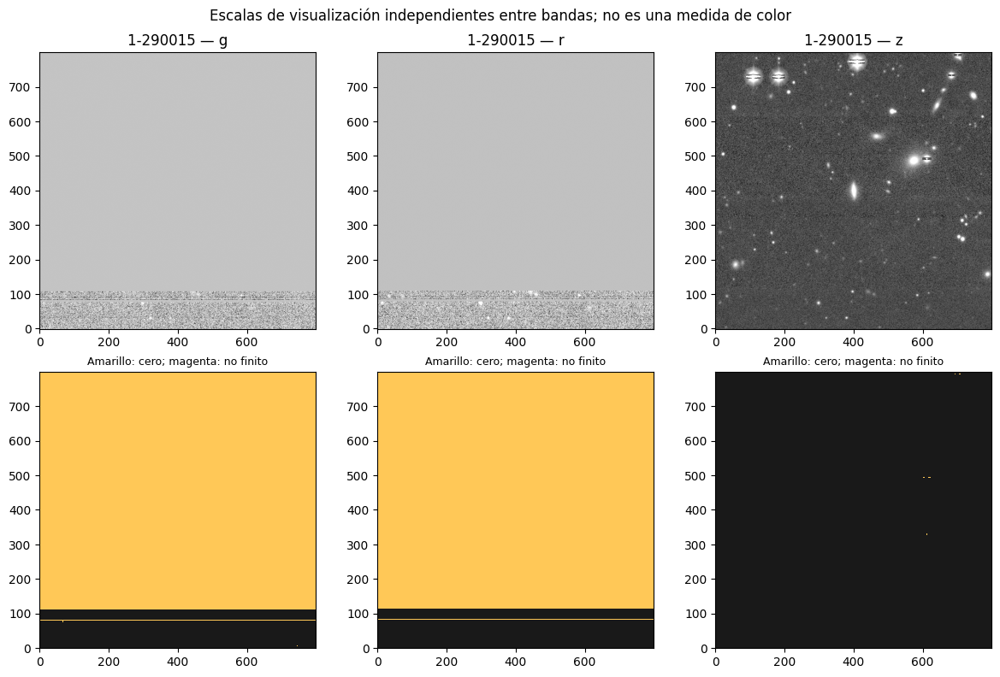

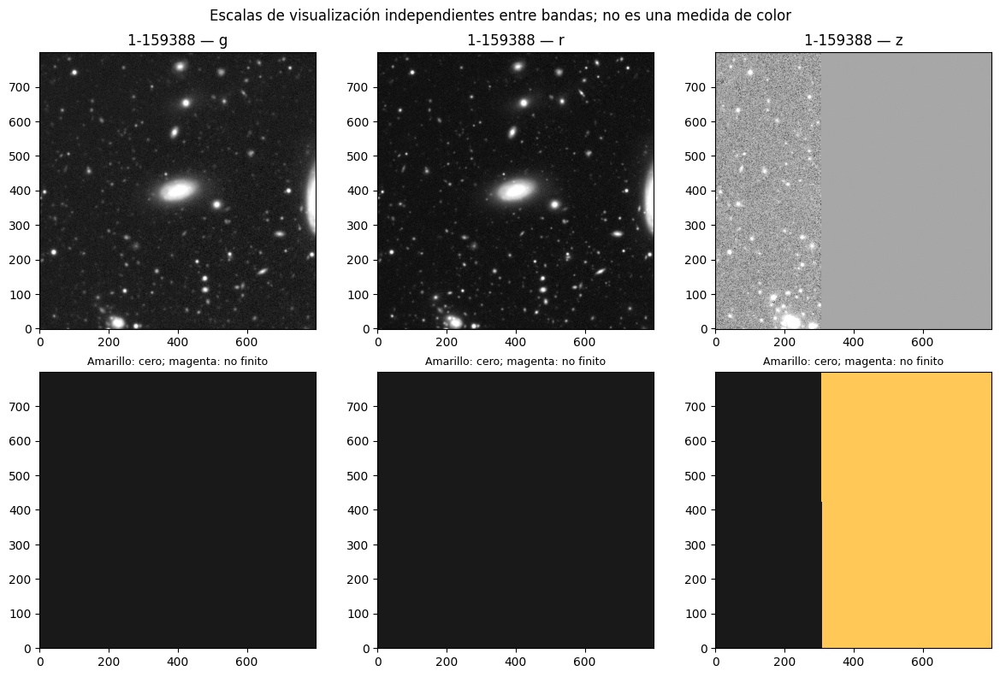

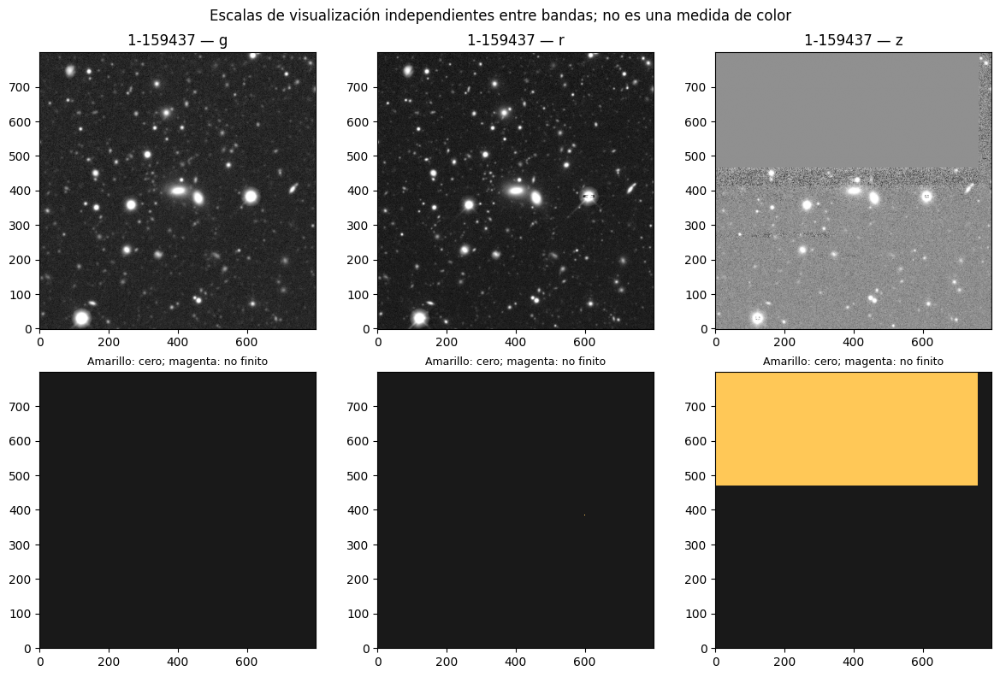

In [21]:
seleccion_galerias = elegir_galerias(inventario_eda, catalogo_geometria,
    estadisticas_fits, lectura_galaxias, CFG, CARPETA_EDA)
generar_galerias(seleccion_galerias, inventario_eda, CFG, CARPETA_EDA)


### 10.1. Cómo interpretamos las galerías y los casos destacados

En las galerías de comparación, **cada renglón corresponde a una galaxia** y las dos columnas muestran la banda r: a la izquierda el campo original y a la derecha el centro. El cuadrado amarillo delimita los 300 × 300 píxeles; el círculo cian representa R90. Estas marcas son referencias geométricas, no máscaras de segmentación ni límites medidos de la fuente en DESI.

La visualización utiliza los percentiles 0.5 y 99.5 y un estiramiento `asinh` con parámetro 0.1. Aplicamos el mismo ajuste a ambos paneles de cada pareja para comparar el cambio de campo. Esta elección facilita observar estructura en un rango amplio de intensidades y es una decisión de representación; los extremos visuales se recortan en la pantalla, no en los FITS. Entre galaxias distintas el ajuste puede cambiar, por lo que no comparamos directamente su brillo aparente en la página.

En las figuras multibanda, las **columnas son g, r y z**; la fila superior muestra la imagen y la inferior localiza ceros y valores no finitos. El amarillo señala ceros y el magenta está reservado a no finitos. Como cada banda puede usar un ajuste propio, estas imágenes no representan una comparación directa de color o flujo.

La galaxia **1-290015** presenta regiones extensas de ceros en g y r, incluido el centro, mientras z conserva estructura visible. En **1-159388** y **1-159437**, las máscaras de z muestran regiones extensas con bordes definidos. Estos patrones justifican consultar información de cobertura y calidad antes de utilizar esos planos científicamente; no permiten identificar por sí solos su causa.

Las galerías incluyen seis ejemplos por varios criterios y cinco BAD porque la selección visual se limita a Train, donde hay cinco BAD. El sexto BAD pertenece a Test y continúa en los conteos completos. Los ejemplos de mayor diámetro, mayor porcentaje de ceros o casos solicitados son selecciones deliberadas: no estimamos frecuencias poblacionales a partir de ellos. Una galaxia puede repetirse entre galerías y esa repetición no aumenta el número de objetos del catálogo.


## 11. Perfiles radiales diagnósticos y señal acumulada

En algunos ejemplos calculamos la media en anillos, la suma acumulada de píxeles finitos y la fracción finita de cada anillo. Centramos el diagnóstico en la coordenada solicitada y limitamos los radios al círculo inscrito en el campo. Usamos la banda r y documentamos los ejemplos.

Estas curvas permiten reconocer cambios del perfil, contribuciones de vecinos y problemas numéricos. **No constituyen una curva de crecimiento de la galaxia aislada**: los archivos ya incorporan el tratamiento de cielo del levantamiento, pero aquí no aislamos fuentes ni estimamos y sustraemos un nuevo fondo. Tampoco corregimos por área faltante. Por ello, no derivamos de estas curvas flujo total, un R90 nuevo ni un porcentaje de luz perdida por el recorte. Las discontinuidades o pendientes motivan una revisión, no una corrección automática.


In [22]:
def perfiles_diagnosticos(sel,inv,cfg,out):
    if not cfg['hacer_perfiles_diagnosticos']:return
    ids=sel.loc[sel.galeria.eq('d90_no_supera_300'),'mangaid'].tolist()
    if not ids:ids=sel.mangaid.drop_duplicates().tolist()
    ids=ids[:cfg['n_perfiles']];lookup=inv.set_index('mangaid',drop=False);reg=[]
    if not ids:return
    p=out/'17_perfiles_diagnosticos_campo.pdf'
    with PdfPages(p) as pdf:
        for g in ids:
            fila=lookup.loc[g].to_dict();datos,hs,_,_=leer_bandas(fila,cfg)
            if 'r' not in datos:continue
            a=datos['r'];wi,w=informacion_wcs(hs['r'],a,fila,cfg)
            if w is None:continue
            x,y,sx,sy=[wi[k] for k in ['objetivo_x_pix','objetivo_y_pix','escala_x_arcsec','escala_y_arcsec']]
            maxr=min((x+.5)*sx,(a.shape[1]-.5-x)*sx,(y+.5)*sy,(a.shape[0]-.5-y)*sy)
            if maxr<=0:continue
            yy,xx=np.indices(a.shape);radio=np.sqrt(((xx-x)*sx)**2+((yy-y)*sy)**2)
            bordes=np.linspace(0,maxr,cfg['anillos_perfil']+1);acum=0;filas=[]
            for lo,hi in zip(bordes[:-1],bordes[1:]):
                mask=(radio>=lo)&(radio<hi);v=a[mask&np.isfinite(a)].astype(float)
                acum+=v.sum();filas.append({'mangaid':g,'radio_exterior_arcsec':hi,'pixeles_anillo':int(mask.sum()),
                    'fraccion_finita':float(len(v)/mask.sum()) if mask.sum() else np.nan,
                    'media_anillo':float(v.mean()) if len(v) else np.nan,'suma_acumulada_finitos':float(acum)})
            d=pd.DataFrame(filas);reg.extend(filas);fig,axs=plt.subplots(1,3,figsize=(14,4))
            for ax,c in zip(axs,['media_anillo','suma_acumulada_finitos','fraccion_finita']):
                ax.plot(d.radio_exterior_arcsec,d[c]);ax.set(xlabel='Radio angular [arcsec]',ylabel=c)
                ax.axvline(cfg['lado_recorte']*cfg['escala_arcsec_pixel']/2,color='#b2182b',ls=':',label='Medio lado nominal de 300')
                if np.isfinite(fila['r90_arcsec']) and fila['r90_arcsec']>0:ax.axvline(fila['r90_arcsec'],color='#168d99',ls='--',label='R90 NSA')
                ax.grid(alpha=.2)
            axs[0].legend(fontsize=6);fig.suptitle(f'{g} — banda r: señal acumulada del campo, con vecinos y fondo residual')
            fig.tight_layout();pdf.savefig(fig);plt.show();plt.close(fig)
    if reg:registrar_pdf(p);guardar_csv(pd.DataFrame(reg),out/'perfiles_diagnosticos_campo.csv')


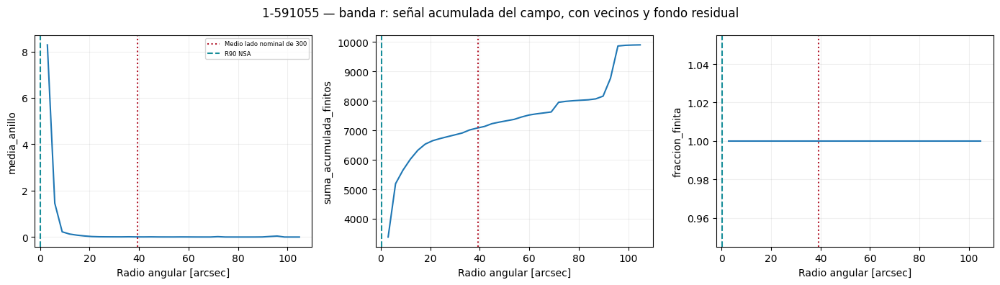

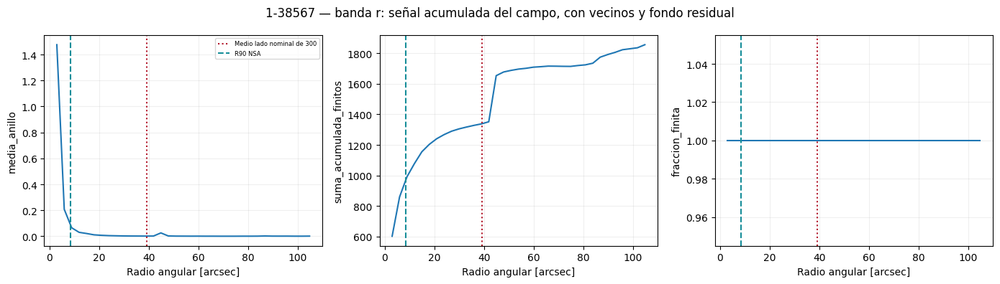

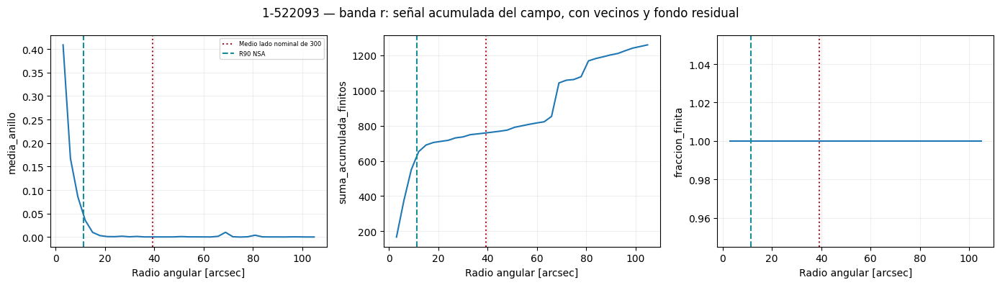

In [23]:
perfiles_diagnosticos(seleccion_galerias, inventario_eda, CFG, CARPETA_EDA)


### 11.1. Lo que muestran los perfiles y lo que no permiten concluir

La media por anillo describe cómo cambia la intensidad alrededor de la coordenada solicitada. La suma acumulada agrega los valores finitos del campo hasta cada radio; por tanto, su pendiente puede incorporar fuentes vecinas y fondo residual. La fracción finita indica disponibilidad numérica y puede ser igual a uno aun cuando haya píxeles de valor cero sin información útil del objetivo.

Los crecimientos exteriores observados no se atribuyen automáticamente a la galaxia central. Tampoco usamos una aparente estabilización de la curva como prueba suficiente de haber recuperado toda su luz. El caso de **1-591055**, con un radio de referencia muy pequeño frente a la estructura mostrada, queda como candidato para revisar la correspondencia y el significado del radio. Conservamos el dato recibido sin recalcularlo a partir de estos perfiles.


## 12. Revisión visual y concordancia opcional con SDSS

Generamos una plantilla con todas las candidatas para documentar identificación del objetivo, vecinos superpuestos, truncamiento, artefactos y observaciones. La plantilla no marca una galaxia como revisada por haber calculado sus estadísticas; todas comienzan como pendientes. Para incorporar una revisión, indicamos la ruta de una copia completada en la configuración.

Si contamos con imágenes RGB originales de SDSS ya exportadas, podemos suministrar un inventario `mangaid,ruta_imagen`. Cruzamos por identificador y mostramos algunos pares. Esto apoya la revisión de identidad, sin confundir renderizados RGB con intensidades FITS calibradas. Las bandas, orientación y escala angular pueden diferir, por lo que no calculamos diferencias de píxeles, PSNR ni SSIM entre imágenes que no han sido puestas en condiciones comparables.

La comparación es opcional y no requiere cargar archivos serializados de Katachi ni entrenar un modelo.


In [24]:
def revision_visual(cat,cfg,out):
    plantilla=cat[['mangaid','particion','grupo_qc']].copy()
    for c in ['galaxia_identificada','vecinos_superpuestos','galaxia_truncada_300','artefactos','observaciones','responsable','fecha_revision']:
        plantilla[c]='PENDIENTE'
    destino=out/'plantilla_revision_visual.csv'
    if not destino.exists():guardar_csv(plantilla,destino)
    if cfg['revision_visual_csv']:
        r=pd.read_csv(cfg['revision_visual_csv'],dtype={'mangaid':'string'},keep_default_na=False)
        if 'mangaid' not in r or r.mangaid.duplicated().any():raise ValueError('Revisión visual: se necesita un mangaid único por fila.')
        guardar_csv(r.loc[r.mangaid.isin(cat.mangaid)],out/'revision_visual_incorporada.csv')
        print('Revisión incorporada; no se interpretan respuestas como exclusiones automáticas.')
    print('Plantilla de revisión:',destino)

def comparar_sdss(sel,inv,cfg,out):
    if not cfg['inventario_sdss_csv']:print('Comparación SDSS opcional no solicitada.');return
    r=pd.read_csv(cfg['inventario_sdss_csv'],dtype={'mangaid':'string'},keep_default_na=False)
    if not {'mangaid','ruta_imagen'}.issubset(r) or r.mangaid.duplicated().any():raise ValueError('Inventario SDSS: mangaid único y ruta_imagen.')
    raiz=Path(cfg['inventario_sdss_csv']).parent
    r['ruta_imagen']=r.ruta_imagen.map(lambda s:str(Path(s) if Path(s).is_absolute() else raiz/s))
    cruce=inv[['mangaid','particion']].merge(r,on='mangaid',how='left',validate='one_to_one',indicator=True)
    guardar_csv(cruce,out/'correspondencia_sdss_desi.csv')
    ejemplos=sel.mangaid.drop_duplicates().tolist()[:cfg['n_ejemplos_por_galeria']]
    r=r.set_index('mangaid');lookup=inv.set_index('mangaid',drop=False);paginas=0;p=out/'18_sdss_desi.pdf'
    with PdfPages(p) as pdf:
        for g in ejemplos:
            if g not in r.index or not Path(r.loc[g,'ruta_imagen']).is_file():continue
            datos,_,_,_=leer_bandas(lookup.loc[g].to_dict(),cfg)
            fig,axs=plt.subplots(1,4,figsize=(14,4));axs[0].imshow(np.asarray(Image.open(r.loc[g,'ruta_imagen'])));axs[0].set_title('SDSS RGB publicado')
            for j,b in enumerate(BANDAS,1):
                if b in datos:axs[j].imshow(np.ma.masked_invalid(datos[b]),origin='lower',cmap='gray',norm=norma_visual(datos[b],cfg))
                axs[j].set_title('DESI '+b+' — campo completo')
            for ax in axs:ax.axis('off')
            fig.suptitle(g+' — concordancia de identidad; campos, orientación y escalas visuales pueden diferir')
            fig.tight_layout();pdf.savefig(fig);plt.show();plt.close(fig);paginas+=1
    if paginas:registrar_pdf(p)


In [25]:
revision_visual(catalogo_eda, CFG, CARPETA_EDA)
comparar_sdss(seleccion_galerias, inventario_eda, CFG, CARPETA_EDA)


Plantilla de revisión: /content/drive/MyDrive/DESI_Candidatas_800_GRZ/resultados_eda/EDA_DESI_candidatas_800_GRZ_v1_1/plantilla_revision_visual.csv
Comparación SDSS opcional no solicitada.


### 12.1. Estado de la revisión científica

La plantilla de revisión fue generada, pero no recibimos en esta ejecución una revisión visual completada de todas las candidatas. Las galerías apoyan el diagnóstico de casos concretos y no equivalen a una aprobación astronómica de las 9,661 galaxias. Asimismo, la salida indica que la comparación opcional con SDSS **no fue solicitada**; no presentamos concordancia visual SDSS–DESI como un resultado de esta ejecución.


## 13. Síntesis, interpretación y productos del EDA

Generamos una síntesis a partir de los conteos medidos y reunimos las figuras de esta ejecución en un PDF. El paquete ZIP incluye ese informe, las figuras, las tablas y la configuración. Los FITS permanecen intactos y no se duplican en el paquete.

La síntesis automática enumera hechos verificables; **completamos la interpretación científica después de revisar tablas y galerías**. Documentamos especialmente:

- Cuántas candidatas tienen g/r/z legibles y geometría esperada, y qué casos siguen pendientes.
- Si los mapas disponibles respaldan la cobertura o si solo tenemos indicios visuales y numéricos.
- Las diferencias entre particiones, grupos QC y galaxias con o sin imágenes disponibles.
- La relación entre tamaño angular y campo, sin convertirla en una estimación injustificada de flujo retenido.
- Las etiquetas o incertidumbres extremas, su procedencia y la evidencia necesaria para interpretarlas.
- Las decisiones ya acordadas y las decisiones adicionales que debamos consultar a los asesores.

Si aparece una incidencia, conservamos su registro. Resolverla o definir una nueva regla de elegibilidad corresponde a una decisión explícita posterior; el notebook no cambia silenciosamente la muestra.


In [26]:
def cerrar_eda(cat,audit,stats,general,cfg,out):
    def contar(col):return int(general[col].fillna(False).sum()) if col in general else 0
    hechos=[f'Analizamos {len(cat):,} galaxias del catálogo candidato y conservamos sus particiones.',
      f'Encontramos tres bandas legibles en {contar("tres_bandas_leidas"):,} galaxias; {contar("forma_grz_esperada"):,} tienen las tres bandas de {cfg["lado_original"]} × {cfg["lado_original"]} píxeles.',
      f'La lectura por sí sola no garantiza cobertura, identidad correcta, ausencia de vecinos ni fiabilidad de etiquetas.',
      'Composición QC: '+', '.join(f'{g}: {len(s):,}' for g,s in cat.groupby('grupo_qc'))+'.',
      'Conservamos todos los registros en el EDA. La decisión vigente excluye WARNING y BAD del experimento; QCFLAG=0 no certifica que cada etiqueta sea correcta.',
      f'El campo nominal de {cfg["lado_original"]} píxeles es {cfg["lado_original"]*cfg["escala_arcsec_pixel"]:.2f} arcsec por lado. El centro de {cfg["lado_recorte"]} píxeles abarca {cfg["lado_recorte"]*cfg["escala_arcsec_pixel"]:.2f} arcsec, sin remuestreo.',
      'R90 es auxiliar geométrico de NSA. La comparación con DESI no mide directamente el porcentaje de flujo de la galaxia que se conserva.',
      'Las intensidades de campo incluyen la galaxia, otras fuentes y fondo residual. No las interpretamos como magnitudes, colores ni flujo aislado del objetivo.',
      'Usamos estiramiento asinh únicamente para visualizar. No definimos normalización de entrenamiento, imputación ni cortes nuevos.',
      'Las estadísticas de Test son descriptivas. Las decisiones sobre el modelo se desarrollan con Train/Validation, reservando Test para la evaluación final.' ]
    originales=stats.loc[stats.region.eq('original')] if len(stats) else stats
    if len(originales):
        hechos.insert(3,f'Entre {len(originales):,} planos originales leídos, {int(originales.porcentaje_no_finito.gt(0).sum()):,} contienen valores no finitos y {int(originales.porcentaje_cero.gt(0).sum()):,} tienen al menos un cero exacto. Los ceros no se clasifican automáticamente como ausencia de cobertura.')
    util=cat.loc[cat.radio_utilizable]
    if len(util):hechos.append(f'De {len(util):,} radios útiles, {int(util.d90_arcsec.gt(cfg["lado_recorte"]*cfg["escala_arcsec_pixel"]).sum()):,} tienen D90 mayor que el campo nominal de {cfg["lado_recorte"]} píxeles.')
    cierre=['Queda pendiente completar la revisión humana y registrar sus conclusiones en la plantilla. Las galerías contienen ejemplos, no toda la muestra.',
       'Si faltan descargas, repetimos inventario y lectura con la misma configuración y carpeta de resultados. Las estadísticas se actualizan cuando cambia el archivo.',
       'Antes del experimento resolvemos identidades, unidades no declaradas, cobertura dudosa y casos extremos con los asesores. Cualquier regla científica adicional debe documentarse y aprobarse.',
       'El presente informe describe los archivos efectivamente disponibles; no extrapolamos hallazgos de un subconjunto al total sin identificar esa limitación.']
    texto='# EDA de imágenes DESI y sus etiquetas\n\n'+ '\n\n'.join(hechos)+'\n\n## Interpretación y pendientes\n\n'+'\n\n'.join(cierre)
    (out/'hallazgos_y_pendientes.md').write_text(texto,encoding='utf-8')
    # Síntesis legible; después añadimos todas las figuras de esta ejecución.
    p=out/'00_sintesis.pdf'
    with PdfPages(p) as pdf:
        paginas=[];lineas=[]
        for parrafo in hechos+cierre:
            nuevas=textwrap.wrap(parrafo,width=99)+['']
            if len(lineas)+len(nuevas)>43:paginas.append(lineas);lineas=[]
            lineas.extend(nuevas)
        if lineas:paginas.append(lineas)
        for i,ls in enumerate(paginas):
            fig=plt.figure(figsize=(8.27,11.69));fig.text(.08,.945,'EDA de imágenes DESI',fontsize=18,weight='bold')
            fig.text(.08,.912,f'Síntesis descriptiva · página {i+1}/{len(paginas)}',fontsize=10)
            fig.text(.08,.865,'\n'.join(ls),fontsize=9,linespacing=1.55,va='top');pdf.savefig(fig);plt.close(fig)
    from pypdf import PdfWriter
    pdf_final=out/'EDA_DESI_informe_completo.pdf';w=PdfWriter();w.append(str(p))
    for f in FIGURAS:
        if f.is_file() and f!=p:w.append(str(f))
    with open(pdf_final,'wb') as f:w.write(f)
    w.close()
    zip_final=out/'EDA_DESI_resultados.zip'
    # No incluimos FITS, caché ni PDFs antiguos ajenos a esta ejecución.
    miembros=[p,pdf_final,*FIGURAS,*[f for f in PRODUCTOS if f.parent==out],out/'plantilla_revision_visual.csv',out/'hallazgos_y_pendientes.md']
    with zipfile.ZipFile(zip_final,'w',zipfile.ZIP_DEFLATED) as z:
        for f in dict.fromkeys(miembros):
            if f.is_file():z.write(f,f.relative_to(out))
    print('\n'.join(hechos[:6]));print('\nPDF:',pdf_final,'\nZIP:',zip_final)
    return pdf_final,zip_final


In [27]:
PDF_EDA, ZIP_EDA = cerrar_eda(catalogo_eda, auditoria_fits, estadisticas_fits, lectura_galaxias, CFG, CARPETA_EDA)


Analizamos 9,661 galaxias del catálogo candidato y conservamos sus particiones.
Encontramos tres bandas legibles en 9,661 galaxias; 9,661 tienen las tres bandas de 800 × 800 píxeles.
La lectura por sí sola no garantiza cobertura, identidad correcta, ausencia de vecinos ni fiabilidad de etiquetas.
Entre 28,983 planos originales leídos, 0 contienen valores no finitos y 2,737 tienen al menos un cero exacto. Los ceros no se clasifican automáticamente como ausencia de cobertura.
Composición QC: BAD: 6, OK: 9,303, WARNING: 352.
Conservamos todos los registros en el EDA. La decisión vigente excluye WARNING y BAD del experimento; QCFLAG=0 no certifica que cada etiqueta sea correcta.

PDF: /content/drive/MyDrive/DESI_Candidatas_800_GRZ/resultados_eda/EDA_DESI_candidatas_800_GRZ_v1_1/EDA_DESI_informe_completo.pdf 
ZIP: /content/drive/MyDrive/DESI_Candidatas_800_GRZ/resultados_eda/EDA_DESI_candidatas_800_GRZ_v1_1/EDA_DESI_resultados.zip


### 13.1. Decisiones descriptivas y fundamento metodológico

| Aspecto detectado | Decisión para esta fase | Fundamento y alcance |
|---|---|---|
| Ausencias en variables auxiliares | Conservamos el registro y utilizamos los pares válidos en cada análisis. | Evitamos perder información disponible de otras propiedades; declaramos el denominador. No demostramos que la ausencia sea aleatoria. |
| Extremos en etiquetas o incertidumbres | Conservamos sus valores y los identificamos para revisión. | Un extremo estadístico puede tener origen físico, de medición o de asociación; el EDA no establece la causa. |
| Alta cardinalidad de MANGAID | Lo mantenemos como identificador. | Permite enlazar imágenes, etiquetas e incidencias; no es una propiedad física para inferencia. |
| Códigos QCFLAG | Los tratamos como categorías de referencia. | Su número no define una distancia ni un orden continuo de calidad. |
| Ceros y valores negativos | Los describimos por frecuencia y localización. | Ser finito no implica cobertura adecuada; ser negativo no confirma un fallo. |
| Diferencia de tamaño entre D90 y campo | La conservamos como diagnóstico geométrico. | No equivale a una medida de señal perdida ni impone una exclusión por sí misma. |
| Ajustes de visualización | Documentamos percentiles, estiramiento y comparabilidad por pareja. | Mejoran la legibilidad sin modificar los valores científicos almacenados. |
| WARNING y BAD | Permanecen en el EDA; distinguimos el acuerdo de exclusión experimental. | Permite describir los objetos afectados y evita presentar una selección futura como aplicada aquí. |

Estas decisiones fijan una lectura coherente de la evidencia, no nuevos umbrales científicos. La revisión con los asesores deberá resolver especialmente el significado de los patrones de ceros, los radios discordantes y la fiabilidad de referencias extremas. Hasta entonces, no convertimos una observación visual en una etiqueta definitiva de aceptación o rechazo.

### 13.2. Conclusiones del análisis exploratorio completo

Confirmamos la disponibilidad técnica de las imágenes de las **9,661 candidatas** y de sus tres bandas, por lo que el alcance actual supera la muestra provisional de 300. La integridad numérica básica es favorable: los 28,983 planos originales son legibles y no contienen NaN ni infinitos. No obstante, la presencia de ceros en 2,737 planos y los patrones espaciales observados muestran que esa comprobación es insuficiente para certificar señal útil en todas las bandas.

La calidad de referencia también requiere una lectura multidimensional. Las 352 WARNING y seis BAD documentan condiciones específicas del catálogo, mientras que los extremos de incertidumbre dentro del grupo OK muestran que un flag sin alerta no garantiza precisión uniforme. Conservamos estas evidencias para interpretar posteriormente los errores del modelo y evitar atribuir todos ellos a la arquitectura.

Las distribuciones de propiedades presentan concentración desigual, colas y asociaciones con dispersión. El parecido general entre particiones facilita una comparación descriptiva, pero no demuestra representatividad ni elimina efectos de selección. Los objetivos son continuos y su evaluación deberá considerar los intervalos poco poblados, además de un promedio global.

La comparación de campos identifica **213 diámetros superiores a 78.6 arcsec y siete superiores a 209.6 arcsec**, entre 9,652 radios utilizables. Esta limitación geométrica debe acompañar cualquier lectura del campo central, sin convertirla en una estimación de flujo retenido. La mayor media central observada en las tres bandas tampoco resuelve esa cuestión.

Concluimos esta etapa con un catálogo caracterizado y casos de revisión identificados, no con una muestra científicamente aprobada en su totalidad ni con resultados predictivos. La aportación del EDA consiste en hacer explícitos los denominadores, las diferencias entre calidad técnica y astronómica, y las decisiones que todavía requieren contraste con los asesores.


## 14. Descargar los resultados a nuestra computadora

El informe y el ZIP se guardan primero en Drive. Las dos celdas siguientes intentan descargarlos a nuestra computadora; autorizamos las descargas en el navegador. **El ZIP contiene también el PDF completo**, además de tablas, figuras y configuración; no incluye los FITS.

Si el navegador bloquea una descarga, abrimos la ruta mostrada desde Google Drive y usamos **Descargar**. No es necesario repetir la auditoría para volver a descargar un resultado ya generado. Si reiniciamos la sesión, estas celdas reconstruyen las rutas a partir de la configuración.


In [28]:
# Descarga del PDF; puede repetirse sin releer las imágenes.
from pathlib import Path
ruta_descarga = Path(CFG['carpeta_resultados']) / CFG['nombre_eda'] / 'EDA_DESI_informe_completo.pdf'
if not ruta_descarga.is_file():
    raise FileNotFoundError('Todavía no se generó el archivo. Ejecuta primero la celda de síntesis: '+str(ruta_descarga))
print('Archivo:', ruta_descarga)
print(f'Tamaño: {ruta_descarga.stat().st_size/1024**2:.2f} MiB')
try:
    from google.colab import files
except ImportError:
    from IPython.display import FileLink, display
    display(FileLink(str(ruta_descarga)))
else:
    print('Iniciando descarga a tu computadora; permite las descargas del navegador.')
    files.download(str(ruta_descarga))


Archivo: /content/drive/MyDrive/DESI_Candidatas_800_GRZ/resultados_eda/EDA_DESI_candidatas_800_GRZ_v1_1/EDA_DESI_informe_completo.pdf
Tamaño: 6.00 MiB
Iniciando descarga a tu computadora; permite las descargas del navegador.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
# Descarga del ZIP; puede repetirse sin releer las imágenes.
from pathlib import Path
ruta_descarga = Path(CFG['carpeta_resultados']) / CFG['nombre_eda'] / 'EDA_DESI_resultados.zip'
if not ruta_descarga.is_file():
    raise FileNotFoundError('Todavía no se generó el archivo. Ejecuta primero la celda de síntesis: '+str(ruta_descarga))
print('Archivo:', ruta_descarga)
print(f'Tamaño: {ruta_descarga.stat().st_size/1024**2:.2f} MiB')
try:
    from google.colab import files
except ImportError:
    from IPython.display import FileLink, display
    display(FileLink(str(ruta_descarga)))
else:
    print('Iniciando descarga a tu computadora; permite las descargas del navegador.')
    files.download(str(ruta_descarga))


Archivo: /content/drive/MyDrive/DESI_Candidatas_800_GRZ/resultados_eda/EDA_DESI_candidatas_800_GRZ_v1_1/EDA_DESI_resultados.zip
Tamaño: 32.69 MiB
Iniciando descarga a tu computadora; permite las descargas del navegador.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Fuentes y procedencia metodológica

Consultamos la documentación técnica de DESI Legacy Imaging Surveys para interpretar sus productos y la documentación de Astropy para separar visualización de valores almacenados:

1. [Legacy Surveys — Preguntas frecuentes: calibración, unidades y visualización](https://www.legacysurvey.org/faq/).
2. [Legacy Surveys DR10 — Descripción: imágenes, escalas y procesamiento del levantamiento](https://www.legacysurvey.org/dr10/description/).
3. [Legacy Surveys DR10 — Productos: imágenes, pesos inversos y número de exposiciones](https://www.legacysurvey.org/dr10/files/).
4. [Astropy — Normalización para visualización](https://docs.astropy.org/en/stable/visualization/normalization.html).
5. [Repositorio original de Katachi](https://github.com/juanpabloalfonzo/Katachi), antecedente de la adaptación y de la comparación opcional con imágenes SDSS.

La selección de gráficas, el registro reanudable y las tablas de este notebook son herramientas descriptivas diseñadas para nuestro proyecto; **no se presentan como una reproducción literal del procedimiento de Katachi o GalEffNet**. La interpretación de QCFLAG y la procedencia NSA de Petro90 corresponden a la información del catálogo y a las aclaraciones recibidas de los asesores. Debemos conservar junto al proyecto la versión del catálogo y su diccionario de columnas.

Comprobamos el flujo con un catálogo y FITS sintéticos, incluidos nombres con código intermedio, bandas reordenadas, archivos duplicados, vacíos, truncados, no finitos, geometría discrepante y reanudación. Esa prueba técnica no sustituye la ejecución ni la revisión científica de las imágenes reales.


### Alcance de la documentación y repositorio del proyecto

Conservamos las celdas originales y sus salidas. Las explicaciones y conclusiones añadidas forman parte de esta libreta; no se incorporan automáticamente al PDF o ZIP que genera el código existente.

El repositorio del equipo es [InferenciaPropiedadesFisicas](https://github.com/erteck/InferenciaPropiedadesFisicas). La entrega deberá enlazar el archivo concreto que publiquemos allí con el nombre requerido por la actividad, una vez confirmado el número del equipo. La edición documental no implica que ya se haya publicado una nueva versión en GitHub.
